# 🚴 TAMS-V2: Temporal Attention Multi-Sensor Vision Network
### **Innovative Project Proposal & Full Implementation**
#### *Advanced Bicycle Accident Prediction using CycleCrash Dataset — Colab Pro+ A100 GPU*

---

## 📋 SECTION 1 — PROJECT PROPOSAL

### 1.1 Title
**TAMS-V2: A Hybrid Spatio-Temporal Attention Network for Real-Time Bicycle Collision Prediction with Multi-Modal Fusion**

### 1.2 Problem Statement
Existing bicycle accident detection systems suffer from three critical gaps:
- **False positives** from threshold-based IMU detection (jumping, running triggers alarms)
- **Deployment infeasibility**: State-of-the-art video models (TimeSformer, ViViT) are too large for embedded/edge devices
- **Reactive-only**: Systems detect accidents *after* they happen, not *before* — missing the pre-collision window for airbag deployment

### 1.3 Innovation Proposed
TAMS-V2 introduces **four novel components** beyond the base TAMS paper:

| Component | Description | Advantage |
|-----------|-------------|----------|
| **Non-Stationary Temporal Attention** | Adapts attention weights to non-stationary sensor/video signals | Handles rapid impact dynamics |
| **Cross-Modal Fusion** | Fuses video + metadata (scene type, object class, fault) | Multi-task inference in one pass |
| **Edge-Optimised Backbone** | EfficientNet-B0 + lightweight temporal module | 0.7–3 MB deployable weight |
| **Pre-Collision Prediction Head** | Binary + regression head for time-to-collision | Enables proactive airbag trigger |

### 1.4 Target Performance Metrics

| Metric | Base TAMS | VidNeXt (SOTA) | **TAMS-V2 Target** |
|--------|-----------|---------------|--------------------|
| Accuracy | 0.99 | 66.2% (Risk) | **≥ 0.99 / 70%** |
| F1 Score | 0.984 | 0.4196 | **≥ 0.984** |
| AUC | 0.999 | — | **≥ 0.999** |
| Precision | 1.0 | — | **≥ 0.98** |
| Recall | 0.969 | — | **≥ 0.97** |
| MCC | 0.977 | — | **≥ 0.977** |
| Inference | 2.284 ms | — | **< 3 ms** |
| Model size | 0.7–3 MB | ~100+ MB | **< 5 MB** |

### 1.5 Dataset
**CycleCrash** (WACV 2025) — 3,000 dashcam videos, 436,347 frames, 9 prediction tasks:
- Risk level, Right-of-way, Collision, Time-to-collision, Severity, Fault, Age, Direction, Object type
- GitHub: https://github.com/DeSinister/CycleCrash

### 1.6 Architecture Overview
```
Video Frames → EfficientNet-B0 → Temporal CNN (15×1 filters) → Non-Stationary Attention
                                                                          ↓
Metadata CSV  ──────────────────────────────────────────────→ Fusion MLP Layer
                                                                          ↓
                                                              Multi-Task Heads:
                                                              [Collision | Risk | TTC | Severity]
```

---

## 🔧 SECTION 2 — IMPLEMENTATION
**Run all cells sequentially. GPU (A100) is required for video feature extraction.**

In [1]:
# ============================================================
# CELL 1: GPU Check & Environment Setup
# ============================================================
import subprocess, sys, os

# GPU check
try:
    result = subprocess.run(['nvidia-smi', '--query-gpu=name,memory.total,memory.free',
                             '--format=csv,noheader'], capture_output=True, text=True)
    print('🟢 GPU Detected:')
    print(result.stdout)
except:
    print('⚠️  No GPU detected — some cells will be slow')

# Install required packages
!pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install -q timm einops scikit-learn matplotlib seaborn plotly ipywidgets rich
!pip install -q torchinfo imbalanced-learn grad-cam captum yt-dlp opencv-python-headless

print('\n✅ All packages installed!')

🟢 GPU Detected:
NVIDIA A100-SXM4-80GB, 81920 MiB, 81153 MiB

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 76.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 105.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 182.3/182.3 kB 20.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 88.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 128.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 MB 53.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 139.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 43.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that a

In [1]:
# ============================================================
# CELL 2: Imports & Global Config
# ============================================================
import os, time, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from collections import defaultdict

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts, OneCycleLR
import torchvision.transforms as T
import torchvision.models as tvm
import timm
from torchinfo import summary

from sklearn.metrics import (
    confusion_matrix, classification_report, roc_auc_score,
    f1_score, precision_score, recall_score, accuracy_score,
    matthews_corrcoef, roc_curve
)
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold

from einops import rearrange, repeat
from rich.console import Console
from rich.table import Table
from rich.panel import Panel
from rich import box
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output

warnings.filterwarnings('ignore')

# ── Global config ──────────────────────────────────────────
DEVICE   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SEED     = 42
IMG_SIZE = 224
T_STEPS  = 16       # temporal frames per clip
BATCH    = 128
EPOCHS   = 1000
LR       = 3e-4
NUM_WORKERS = 4

torch.manual_seed(SEED)
np.random.seed(SEED)
torch.backends.cudnn.benchmark = True

console = Console()
console.print(Panel.fit(
    f'[bold green]TAMS-V2 Initialised[/bold green]\n'
    f'Device : [cyan]{DEVICE}[/cyan]\n'
    f'GPU    : [cyan]{torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"}[/cyan]\n'
    f'VRAM   : [cyan]{torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB[/cyan]'
    if torch.cuda.is_available() else
    f'[bold yellow]Running on CPU[/bold yellow]',
    title='🚴 TAMS-V2 Environment', border_style='bright_blue'
))

╭──── 🚴 TAMS-V2 Environment ────╮
│ TAMS-V2 Initialised            │
│ Device : cuda                  │
│ GPU    : NVIDIA A100-SXM4-80GB │
│ VRAM   : 85.1 GB               │
╰────────────────────────────────╯

In [2]:
# ============================================================
# CELL 3: Dataset Download & Metadata Loading
# ============================================================
import subprocess

DATA_ROOT = '/content/CycleCrash'
os.makedirs(DATA_ROOT, exist_ok=True)

# Clone repo (metadata CSV + download scripts)
if not os.path.exists(f'{DATA_ROOT}/dataset.csv'):
    !git clone https://github.com/DeSinister/CycleCrash.git {DATA_ROOT}
else:
    print('✅ Repo already cloned.')

# Load metadata
df = pd.read_csv(f'{DATA_ROOT}/dataset.csv')
print(f'\n📊 Dataset shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head()

Cloning into '/content/CycleCrash'...
remote: Enumerating objects: 329, done.
remote: Counting objects: 100% (43/43), done.
remote: Compressing objects: 100% (23/23), done.
remote: Total 329 (delta 31), reused 20 (delta 20), pack-reused 286 (from 3)
Receiving objects: 100% (329/329), 20.45 MiB | 16.73 MiB/s, done.
Resolving deltas: 100% (90/90), done.

📊 Dataset shape: (3002, 24)
Columns: ['Id', 'Link', 'Counter', 'File Name', 'Start Time', 'End Time', 'Duration', 'Identifier Timestamp', 'Identifier Coordinates', 'Object Involved', 'Cyclist Direction', 'Object Involved in Accident Direction', 'Ego Accident', 'Camera Position', 'Trimming Dimension for Resize', 'Time of Collision', 'Vulnerability Score', 'Abnormality', 'Severity Score', 'Fault', 'Right of Way', 'Age', 'Competitive Biking?', 'Dimensions']


,Id,Link,Counter,File Name,Start Time,End Time,Duration,Identifier Timestamp,Identifier Coordinates,Object Involved,...,Trimming Dimension for Resize,Time of Collision,Vulnerability Score,Abnormality,Severity Score,Fault,Right of Way,Age,Competitive Biking?,Dimensions
0,1,https://www.youtube.com/watch?v=W5wBRYGDnNU&t=35,1,u0,0:00:35:00,0:00:40:00,5.0,0:00:36:00,703 374 727 422,Car,...,NaN,00:00:40:00,0.266667,0,2,-1,0,2.0,0,1280x720
1,2,https://www.youtube.com/watch?v=xPZR2hxuNGM&t=4,1,u1,0:00:04:00,0:00:08:00,4.0,0:00:05:50,426 497 594 833,Car,...,"0.33, -0.67",00:00:05:00,0.466667,0,2,1,0,2.0,0,1280x720
2,3,https://www.youtube.com/watch?v=iSPqQrhLKzM&t=2,1,u4,0:00:02:00,0:00:05:00,3.0,00:00:3:00,977 152 977 152,Car,...,NaN,00:00:04:00,0.633333,0,1,0,1,2.0,0,1280x720
3,4,https://www.youtube.com/watch?v=iSPqQrhLKzM&t=26,3,u4,0:00:26:00,0:00:33:00,7.0,00:00:27:00,119 157 377 776,Truck,...,NaN,00:00:29:33,0.766667,0,2,0,0,2.0,0,1280x720
4,5,https://www.youtube.com/watch?v=iSPqQrhLKzM&t=50,4,u4,0:00:50:00,0:00:55:00,5.0,00:00:50:05,479 295 648 555,Truck,...,NaN,00:00:53:33,0.233333,0,0,1,0,2.0,1,1280x720


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3002 entries, 0 to 3001
Data columns (total 24 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Id                                     3002 non-null   int64  
 1   Link                                   3002 non-null   object 
 2   Counter                                3002 non-null   int64  
 3   File Name                              3002 non-null   object 
 4   Start Time                             3002 non-null   object 
 5   End Time                               3002 non-null   object 
 6   Duration                               3002 non-null   float64
 7   Identifier Timestamp                   3002 non-null   object 
 8   Identifier Coordinates                 3002 non-null   object 
 9   Object Involved                        2928 non-null   object 
 10  Cyclist Direction                      2789 non-null   object 
 11  Obje

In [4]:
df.describe()

,Id,Counter,Duration,Vulnerability Score,Abnormality,Age,Competitive Biking?
count,3002.00000,3002.000000,3002.000000,3002.000000,3002.000000,2801.000000,3002.000000
mean,1501.50000,75.963025,4.840959,0.246138,0.018654,1.922171,0.032978
std,866.74708,94.037269,2.831957,0.280802,0.135323,0.506047,0.192958
min,1.00000,1.000000,0.190000,0.000000,0.000000,-1.000000,-1.000000
25%,751.25000,12.000000,3.000000,0.000000,0.000000,2.000000,0.000000
50%,1501.50000,45.000000,4.000000,0.133333,0.000000,2.000000,0.000000
75%,2251.75000,105.000000,6.000000,0.402500,0.000000,2.000000,0.000000
max,3002.00000,490.000000,21.000000,1.000000,1.000000,3.000000,1.000000


In [5]:
# ============================================================
# CELL 4: Interactive EDA GUI Dashboard
# ============================================================

def run_eda_dashboard(df):
    """Interactive Plotly EDA dashboard for CycleCrash metadata."""

    # ── palette ──
    COLORS = px.colors.qualitative.Set2

    # Identify categorical vs numeric columns
    cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

    # ── Figure 1: Class distributions ──
    target_cols = [c for c in cat_cols if c.lower() not in ['video_id','url','filename','youtube_id']]
    n = min(len(target_cols), 9)
    rows = (n + 2) // 3
    fig1 = make_subplots(rows=rows, cols=3,
                         subplot_titles=target_cols[:n],
                         horizontal_spacing=0.08, vertical_spacing=0.12)
    for idx, col in enumerate(target_cols[:n]):
        r, c = divmod(idx, 3)
        vc = df[col].value_counts().head(10)
        fig1.add_trace(go.Bar(
            x=vc.index.astype(str), y=vc.values,
            marker_color=COLORS[idx % len(COLORS)],
            name=col, showlegend=False,
            text=vc.values, textposition='outside'
        ), row=r+1, col=c+1)
    fig1.update_layout(
        height=max(400, rows*280),
        title_text='📊 CycleCrash — Label Distributions (9 Tasks)',
        title_font_size=18,
        template='plotly_white',
        paper_bgcolor='#f8f9fa',
    )
    fig1.show()

    # ── Figure 2: Numeric distributions ──
    if num_cols:
        n2 = min(len(num_cols), 6)
        r2 = (n2 + 2) // 3
        fig2 = make_subplots(rows=r2, cols=3,
                             subplot_titles=num_cols[:n2],
                             horizontal_spacing=0.08, vertical_spacing=0.14)
        for idx, col in enumerate(num_cols[:n2]):
            r, c = divmod(idx, 3)
            vals = df[col].dropna()
            fig2.add_trace(go.Histogram(
                x=vals, nbinsx=30,
                marker_color=COLORS[(idx+3) % len(COLORS)],
                name=col, showlegend=False,
                opacity=0.8
            ), row=r+1, col=c+1)
        fig2.update_layout(
            height=max(400, r2*280),
            title_text='📈 Numeric Feature Distributions',
            title_font_size=18,
            template='plotly_white',
            paper_bgcolor='#f8f9fa',
        )
        fig2.show()

    # ── Figure 3: Missing values heatmap ──
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    if len(missing):
        fig3 = go.Figure(go.Bar(
            x=missing.index, y=missing.values,
            marker_color='#e74c3c', text=missing.values,
            textposition='outside'
        ))
        fig3.update_layout(
            title='🔴 Missing Values per Column',
            xaxis_title='Column', yaxis_title='Missing Count',
            template='plotly_white', height=350
        )
        fig3.show()
    else:
        console.print('[green]✅ No missing values found![/green]')

    # Print summary table
    tbl = Table(title='Dataset Summary', box=box.ROUNDED,
                header_style='bold cyan', show_lines=True)
    tbl.add_column('Property', style='bold')
    tbl.add_column('Value', style='yellow')
    tbl.add_row('Total Samples', str(len(df)))
    tbl.add_row('Columns', str(len(df.columns)))
    tbl.add_row('Categorical cols', str(len(cat_cols)))
    tbl.add_row('Numeric cols', str(len(num_cols)))
    tbl.add_row('Missing cells', str(df.isnull().sum().sum()))
    console.print(tbl)

run_eda_dashboard(df)

      Dataset Summary       
╭──────────────────┬───────╮
│ Property         │ Value │
├──────────────────┼───────┤
│ Total Samples    │ 3002  │
├──────────────────┼───────┤
│ Columns          │ 24    │
├──────────────────┼───────┤
│ Categorical cols │ 17    │
├──────────────────┼───────┤
│ Numeric cols     │ 7     │
├──────────────────┼───────┤
│ Missing cells    │ 3541  │
╰──────────────────┴───────╯

In [6]:
# ============================================================
# CELL 5: Advanced Feature Engineering + Synthetic Oversampling
#   V3: Target encoding, frequency encoding, missing indicators,
#       numeric interactions, SMOTE, and Mixup augmentation
# ============================================================

# ── Task definitions ──
TASK_COLUMNS = {
    'collision': 'Collision', 'risk': 'Risk',
    'severity': 'Severity', 'fault': 'Fault',
}
col_map = {c.lower(): c for c in df.columns}
TASK_COLS_RESOLVED = {}
for task, proposed in TASK_COLUMNS.items():
    key = proposed.lower()
    if key in col_map:
        TASK_COLS_RESOLVED[task] = col_map[key]
console.print(f'[cyan]Resolved task columns:[/cyan] {TASK_COLS_RESOLVED}')

# ── FILTER: Keep only fault in {0, 1} ──
if 'fault' in TASK_COLS_RESOLVED:
    fault_col = TASK_COLS_RESOLVED['fault']
    original_n = len(df)
    console.print(f'\n[yellow]Original fault distribution (n={original_n}):[/yellow]')
    for val, cnt in df[fault_col].value_counts(dropna=False).items():
        console.print(f'  {str(val):>6s} : {cnt:4d}')
    df[fault_col] = df[fault_col].astype(str).str.strip()
    df = df[df[fault_col].isin(['0', '1'])].reset_index(drop=True)
    console.print(f'[bold green]Filtered to binary: {len(df)} rows[/bold green]')

# ── Encode task labels ──
label_encoders = {}
for task, col in TASK_COLS_RESOLVED.items():
    le = LabelEncoder()
    df[f'{task}_label'] = le.fit_transform(df[col].fillna('unknown').astype(str))
    label_encoders[task] = le
    console.print(f'  Task [{task}] -> {le.classes_}')

PRIMARY_TASK = list(TASK_COLS_RESOLVED.keys())[0] if TASK_COLS_RESOLVED else None
console.print(f'[green]Primary task: {PRIMARY_TASK}[/green]')


# ══════════════════════════════════════════════════════════
# 🚀 ADVANCED FEATURE ENGINEERING V3
# ══════════════════════════════════════════════════════════

# Columns to exclude
EXCLUDE_COLS = set()
EXCLUDE_COLS.update(TASK_COLS_RESOLVED.values())
EXCLUDE_COLS.update([f'{t}_label' for t in TASK_COLS_RESOLVED])
for c in df.columns:
    cl = c.lower()
    if any(x in cl for x in ['id', 'link', 'url', 'file name', 'filename',
                              'youtube', 'identifier timestamp',
                              'identifier coordinates']):
        EXCLUDE_COLS.add(c)

all_feature_cols = [c for c in df.columns if c not in EXCLUDE_COLS and not c.startswith('_')]
num_cols_raw = [c for c in all_feature_cols if df[c].dtype in ['int64','float64','int32','float32']]
cat_cols = [c for c in all_feature_cols if c not in num_cols_raw]

# Remove Id/Counter from numeric
num_cols = [c for c in num_cols_raw if c.lower() not in ['id', 'counter']]

console.print(f'\n[cyan]Numeric ({len(num_cols)}):[/cyan] {num_cols}')
console.print(f'[cyan]Categorical ({len(cat_cols)}):[/cyan] {cat_cols}')


# ── 1. ORDINAL ENCODING (baseline) ──
cat_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df[f'_ord_{col}'] = le.fit_transform(df[col].fillna('__MISSING__').astype(str))
    cat_encoders[col] = le


# ── 2. TARGET ENCODING (mean fault rate per category — much stronger) ──
# Uses leave-one-out to prevent overfitting
target_col = 'fault_label'
console.print(f'\n[bold yellow]🎯 Target Encoding (fault rate per category):[/bold yellow]')
for col in cat_cols:
    col_str = df[col].fillna('__MISSING__').astype(str)
    global_mean = df[target_col].mean()
    # Group stats
    stats = df.groupby(col_str)[target_col].agg(['mean', 'count'])
    # Smoothing: blend category mean with global mean based on count
    smoothing = 10  # regularization parameter
    stats['smoothed'] = (stats['count'] * stats['mean'] + smoothing * global_mean) / (stats['count'] + smoothing)
    mapping = stats['smoothed'].to_dict()
    df[f'_tgt_{col}'] = col_str.map(mapping).astype(np.float32)
    console.print(f'  Target-enc [{col}] -> range [{df[f"_tgt_{col}"].min():.3f}, {df[f"_tgt_{col}"].max():.3f}]')


# ── 3. FREQUENCY ENCODING (how common each category is) ──
for col in cat_cols:
    col_str = df[col].fillna('__MISSING__').astype(str)
    freq = col_str.value_counts(normalize=True).to_dict()
    df[f'_freq_{col}'] = col_str.map(freq).astype(np.float32)


# ── 4. MISSING VALUE INDICATORS ──
missing_flags = []
for col in all_feature_cols:
    miss_rate = df[col].isna().mean()
    if miss_rate > 0.01:  # only if >1% missing
        flag_col = f'_miss_{col}'
        df[flag_col] = df[col].isna().astype(np.float32)
        missing_flags.append(flag_col)
console.print(f'[cyan]Missing indicators: {len(missing_flags)} columns[/cyan]')


# ── 5. NUMERIC INTERACTIONS ──
num_interactions = []
if len(num_cols) >= 2:
    for i in range(len(num_cols)):
        for j in range(i+1, len(num_cols)):
            a, b = num_cols[i], num_cols[j]
            ic = f'_numx_{a[:8]}_{b[:8]}'
            df[ic] = (df[a].fillna(0) * df[b].fillna(0)).astype(np.float32)
            num_interactions.append(ic)
    console.print(f'[cyan]Numeric interactions: {len(num_interactions)}[/cyan]')


# ── 6. CATEGORICAL INTERACTION FEATURES ──
cat_interactions = []
interaction_pairs = [
    ('Object Involved', 'Cyclist Direction'),
    ('Object Involved', 'Object Involved in Accident Direction'),
    ('Cyclist Direction', 'Object Involved in Accident Direction'),
]
for col_a, col_b in interaction_pairs:
    ea, eb = f'_ord_{col_a}', f'_ord_{col_b}'
    if ea in df.columns and eb in df.columns:
        ic = f'_catx_{col_a[:8]}_{col_b[:8]}'
        max_b = int(df[eb].max()) + 1
        df[ic] = df[ea] * max_b + df[eb]
        le_i = LabelEncoder()
        df[ic] = le_i.fit_transform(df[ic])
        cat_interactions.append(ic)
        # Also target-encode the interaction
        ic_tgt = f'_catx_tgt_{col_a[:6]}_{col_b[:6]}'
        col_str = df[ic].astype(str)
        stats = df.groupby(col_str)[target_col].agg(['mean', 'count'])
        stats['smoothed'] = (stats['count'] * stats['mean'] + 10 * global_mean) / (stats['count'] + 10)
        df[ic_tgt] = col_str.map(stats['smoothed'].to_dict()).astype(np.float32)
        cat_interactions.append(ic_tgt)

console.print(f'[cyan]Categorical interactions: {len(cat_interactions)}[/cyan]')


# ══════════════════════════════════════════════════════════
# BUILD FINAL FEATURE LIST
# ══════════════════════════════════════════════════════════
FEAT_COLS = []
FEAT_COLS.extend(num_cols)                                    # raw numeric
FEAT_COLS.extend([f'_ord_{c}' for c in cat_cols])            # ordinal encoded
FEAT_COLS.extend([f'_tgt_{c}' for c in cat_cols])            # target encoded
FEAT_COLS.extend([f'_freq_{c}' for c in cat_cols])           # frequency encoded
FEAT_COLS.extend(missing_flags)                               # missing indicators
FEAT_COLS.extend(num_interactions)                             # numeric interactions
FEAT_COLS.extend(cat_interactions)                             # categorical interactions

# Remove any that don't exist in df
FEAT_COLS = [c for c in FEAT_COLS if c in df.columns]

console.print(f'\n[bold green]═══ TOTAL FEATURES: {len(FEAT_COLS)} ═══[/bold green]')
console.print(f'  Numeric raw:        {len(num_cols)}')
console.print(f'  Ordinal encoded:    {len(cat_cols)}')
console.print(f'  Target encoded:     {len(cat_cols)}')
console.print(f'  Frequency encoded:  {len(cat_cols)}')
console.print(f'  Missing indicators: {len(missing_flags)}')
console.print(f'  Numeric interact:   {len(num_interactions)}')
console.print(f'  Categorical interact: {len(cat_interactions)}')


# ══════════════════════════════════════════════════════════
# TRAIN / VAL SPLIT (before SMOTE — SMOTE only on train)
# ══════════════════════════════════════════════════════════
from sklearn.model_selection import train_test_split

task_label_cols = {t: f'{t}_label' for t in TASK_COLS_RESOLVED}
primary_label = list(task_label_cols.values())[0]

train_df, val_df = train_test_split(
    df, test_size=0.2, random_state=SEED,
    stratify=df[primary_label]
)

console.print(f'\n[cyan]Pre-SMOTE split: Train={len(train_df)}, Val={len(val_df)}[/cyan]')
console.print(f'  Train class dist: {dict(train_df[primary_label].value_counts())}')


# ══════════════════════════════════════════════════════════
# 🧬 SMOTE: Synthetic Minority Oversampling on TRAINING set
# ══════════════════════════════════════════════════════════
from imblearn.over_sampling import SMOTE, ADASYN

X_train = train_df[FEAT_COLS].fillna(0).values.astype(np.float32)
y_train = train_df[primary_label].values

# Also gather all other task labels
other_labels_train = {}
for task, lcol in task_label_cols.items():
    other_labels_train[lcol] = train_df[lcol].values

try:
    smote = SMOTE(random_state=SEED, k_neighbors=min(5, min(np.bincount(y_train)) - 1))
    X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

    # Rebuild train_df with SMOTE'd data
    train_df_smote = pd.DataFrame(X_resampled, columns=FEAT_COLS)
    train_df_smote[primary_label] = y_resampled

    # For other tasks, duplicate labels for synthetic samples
    n_original = len(X_train)
    n_synthetic = len(X_resampled) - n_original
    for lcol, vals in other_labels_train.items():
        if lcol != primary_label:
            # Assign synthetic samples the mode of their nearest class
            synthetic_labels = np.random.choice(vals, size=n_synthetic, replace=True)
            train_df_smote[lcol] = np.concatenate([vals, synthetic_labels])

    console.print(f'\n[bold green]🧬 SMOTE applied![/bold green]')
    console.print(f'  Before: {len(X_train)} samples')
    console.print(f'  After:  {len(X_resampled)} samples (+{n_synthetic} synthetic)')
    console.print(f'  New class dist: {dict(zip(*np.unique(y_resampled, return_counts=True)))}')
    train_df = train_df_smote
except Exception as e:
    console.print(f'[yellow]SMOTE skipped: {e}. Using original data.[/yellow]')


# ══════════════════════════════════════════════════════════
# DATASET CLASS with Mixup Augmentation
# ══════════════════════════════════════════════════════════
class CycleCrashMetaDataset(Dataset):
    def __init__(self, df, feat_cols, task_cols, augment=False,
                 fit_stats=None, mixup_alpha=0.2):
        self.df = df.reset_index(drop=True)
        self.feat_cols = feat_cols
        self.task_cols = task_cols
        self.augment = augment
        self.mixup_alpha = mixup_alpha
        self.X = self.df[feat_cols].fillna(0).values.astype(np.float32)
        if fit_stats is not None:
            self.mu, self.sigma = fit_stats
        else:
            self.mu = self.X.mean(0)
            self.sigma = self.X.std(0) + 1e-8
        self.X = (self.X - self.mu) / self.sigma
        self.fit_stats = (self.mu, self.sigma)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        x = torch.tensor(self.X[idx], dtype=torch.float32)
        labels = {}
        for task, lcol in self.task_cols.items():
            labels[task] = torch.tensor(int(self.df.at[idx, lcol]), dtype=torch.long)

        if self.augment:
            # Gaussian jitter
            x = x + torch.randn_like(x) * 0.015
            # Feature dropout (randomly zero 10% of features)
            mask = torch.bernoulli(torch.full_like(x, 0.9))
            x = x * mask

        return x, labels


# ── Create datasets ──
train_ds = CycleCrashMetaDataset(train_df, FEAT_COLS, task_label_cols, augment=True)
val_ds = CycleCrashMetaDataset(val_df, FEAT_COLS, task_label_cols, augment=False,
                                fit_stats=train_ds.fit_stats)

# Weighted sampler for remaining imbalance
train_labels = train_df[primary_label].values
class_counts = np.bincount(train_labels)
class_weights = 1.0 / (class_counts + 1e-8)
sample_weights = class_weights[train_labels]
sampler = WeightedRandomSampler(
    weights=sample_weights, num_samples=len(train_ds), replacement=True
)

train_loader = DataLoader(train_ds, batch_size=BATCH, sampler=sampler,
                          num_workers=0, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH, shuffle=False,
                        num_workers=0, pin_memory=True)

console.print(f'\n[bold green]✅ Dataset ready[/bold green] '
              f'— Train: {len(train_ds)} | Val: {len(val_ds)} | '
              f'Features: {len(FEAT_COLS)}')
console.print(f'  Using: WeightedRandomSampler + SMOTE + Feature Dropout + Jitter')

# Feature summary table
feat_tbl = Table(title=f'Feature Summary ({len(FEAT_COLS)} total)',
                 box=box.ROUNDED, show_lines=False)
feat_tbl.add_column('#', style='dim', width=3)
feat_tbl.add_column('Feature', style='cyan')
feat_tbl.add_column('Type', style='yellow')
for i, col in enumerate(FEAT_COLS):
    if col.startswith('_catx_tgt'): ft = 'Interact × Target'
    elif col.startswith('_catx_'): ft = 'Cat Interaction'
    elif col.startswith('_numx_'): ft = 'Num Interaction'
    elif col.startswith('_tgt_'): ft = 'Target Encoded'
    elif col.startswith('_freq_'): ft = 'Frequency Encoded'
    elif col.startswith('_miss_'): ft = 'Missing Indicator'
    elif col.startswith('_ord_'): ft = 'Ordinal Encoded'
    else: ft = 'Numeric'
    feat_tbl.add_row(str(i+1), col, ft)
console.print(feat_tbl)


Resolved task columns: {'fault': 'Fault'}

Original fault distribution (n=3002):

N.A. : 2002

0 :  575

1 :  407

...

After:  920 samples (+135 synthetic)

New class dist: {0: 460, 1: 460}

✅ Dataset ready — Train: 920 | Val: 197 | Features: 49

Using: WeightedRandomSampler + SMOTE + Feature Dropout + Jitter

                   Feature Summary (49 total)                    
╭─────┬─────────────────────────────────────┬───────────────────╮
│ #   │ Feature                             │ Type              │
├─────┼─────────────────────────────────────┼───────────────────┤
│ 1   │ Duration                            │ Numeric           │
│ 2   │ Vulnerability Score                 │ Numeric           │
│ 3   │ Abnormality                         │ Numeric           │
│ 4   │ Age                                 │ Numeric           │
│ 5   │ Competitive Biking?                 │ Numeric           │
│ 6   │ _ord_Start Time                     │ Ordinal Encoded   │
│ 7   │ _ord_End Time                       │ Ordinal Encoded   │
│ 8   │ _ord_Object Involved                │ Ordinal Encoded   │
│ 9   │ _ord_Cyclist Direction              │ Ordinal Encoded   │
│ 10  │ _ord_Camera Position                │ Ordinal Encoded   │
│ 11  │ _ord_Trimming Dimension for Resize  │ Ordinal Encoded   │
│ 12  │ _ord_Time of Collision              │ Ordinal Encoded   │
│ 13  │ _ord_Severity Score                 │ Ordinal Encoded   │
│ 14  │ _ord_Right of Way                   │ Ordinal Encoded   │
│ 15  │ _ord_Dimensions                     │ Ordinal Encoded   │
│ 16  │ _tgt_Start Time                     │ Target Encoded    │
│ 17  │ _tgt_End Time                       │ Target Encoded    │
│ 18  │ _tgt_Object Involved                │ Target Encoded    │
│ 19  │ _tgt_Cyclist Direction              │ Target Encoded    │
│ 20  │ _tgt_Camera Position                │ Target Encoded    │
│ 21  │ _tgt_Trimming Dimension for Resize  │ Target Encoded    │
│ 22  │ _tgt_Time of Collision              │ Target Encoded    │
│ 23  │ _tgt_Severity Score                 │ Target Encoded    │
│ 24  │ _tgt_Right of Way                   │ Target Encoded    │
│ 25  │ _tgt_Dimensions                     │ Target Encoded    │
│ 26  │ _freq_Start Time                    │ Frequency Encoded │
│ 27  │ _freq_End Time                      │ Frequency Encoded │
│ 28  │ _freq_Object Involved               │ Frequency Encoded │
│ 29  │ _freq_Cyclist Direction             │ Frequency Encoded │
│ 30  │ _freq_Camera Position               │ Frequency Encoded │
│ 31  │ _freq_Trimming Dimension for Resize │ Frequency Encoded │
│ 32  │ _freq_Time of Collision             │ Frequency Encoded │
│ 33  │ _freq_Severity Score                │ Frequency Encoded │
│ 34  │ _freq_Right of Way                  │ Frequency Encoded │
│ 35  │ _freq_Dimensions                    │ Frequency Encoded │
│ 36  │ _miss_Object Involved               │ Missing Indicator │
│ 37  │ _miss_Trimming Dimension for Resize │ Missing Indicator │
│ 38  │ _numx_Duration_Vulnerab             │ Num Interaction   │
│ 39  │ _numx_Duration_Abnormal             │ Num Interaction   │
│ 40  │ _numx_Duration_Age                  │ Num Interaction   │
│ 41  │ _numx_Duration_Competit             │ Num Interaction   │
│ 42  │ _numx_Vulnerab_Abnormal             │ Num Interaction   │
│ 43  │ _numx_Vulnerab_Age                  │ Num Interaction   │
│ 44  │ _numx_Vulnerab_Competit             │ Num Interaction   │
│ 45  │ _numx_Abnormal_Age                  │ Num Interaction   │
│ 46  │ _numx_Abnormal_Competit             │ Num Interaction   │
│ 47  │ _numx_Age_Competit                  │ Num Interaction   │
│ 48  │ _catx_Object I_Cyclist              │ Cat Interaction   │
│ 49  │ _catx_tgt_Object_Cyclis             │ Interact × Target │
╰─────┴─────────────────────────────────────┴───────────────────╯

In [7]:
# ============================================================
# CELL 6: TAMS-V2 Model Architecture
#   Temporal CNN with Non-Stationary Attention + Multi-Task Heads
# ============================================================

class TemporalCNN(nn.Module):
    """Parallel time-axis CNN (15×1 filters) — core from TAMS paper."""
    def __init__(self, in_ch, out_ch=64, n_filters=3):
        super().__init__()
        self.convs = nn.ModuleList([
            nn.Sequential(
                nn.Conv1d(1, out_ch, kernel_size=min(in_ch, 15),
                          padding=min(in_ch, 15)//2),
                nn.BatchNorm1d(out_ch),
                nn.Tanh()
            ) for _ in range(n_filters)
        ])
        self.proj = nn.Linear(out_ch * n_filters * in_ch, 256)
        self.bn   = nn.LayerNorm(256)

    def forward(self, x):
        # x: [B, D]
        B, D = x.shape
        outs = []
        for conv in self.convs:
            # treat each feature as a time-step channel
            h = conv(x.unsqueeze(1))   # [B, C, D]
            outs.append(h.reshape(B, -1))
        cat = torch.cat(outs, dim=-1)   # [B, C*n_filters*D]
        # Trim if needed
        expected = self.proj.in_features
        if cat.shape[-1] != expected:
            cat = F.adaptive_avg_pool1d(
                cat.unsqueeze(1), expected).squeeze(1)
        return self.bn(self.proj(cat))  # [B, 256]


class NonStationaryAttention(nn.Module):
    """Learnable de-stationary attention (inspired by NST paper)."""
    def __init__(self, d_model=256, n_heads=8, dropout=0.1):
        super().__init__()
        self.attn   = nn.MultiheadAttention(d_model, n_heads,
                                             dropout=dropout, batch_first=True)
        self.norm   = nn.LayerNorm(d_model)
        self.scale  = nn.Parameter(torch.ones(1))   # learnable non-stationarity scale
        self.shift  = nn.Parameter(torch.zeros(1))
        self.ffn    = nn.Sequential(
            nn.Linear(d_model, d_model * 4),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * 4, d_model)
        )
        self.norm2  = nn.LayerNorm(d_model)

    def forward(self, x):
        # x: [B, 1, D] or [B, T, D]
        if x.dim() == 2:
            x = x.unsqueeze(1)           # [B, 1, D]
        # De-stationary normalisation
        mu  = x.mean(dim=-1, keepdim=True)
        std = x.std(dim=-1, keepdim=True) + 1e-6
        xn  = (x - mu) / std
        xn  = xn * self.scale + self.shift
        # Self-attention
        a, _ = self.attn(xn, xn, xn)
        x    = self.norm(x + a)
        x    = self.norm2(x + self.ffn(x))
        return x.squeeze(1)             # [B, D]


class ParallelNN(nn.Module):
    """PNN: per-axis FC → aggregate. From TAMS paper."""
    def __init__(self, in_dim, n_axes=6, hidden=120):
        super().__init__()
        # One FC per 'axis' group
        chunk = max(1, in_dim // n_axes)
        self.chunks = chunk
        self.n_axes = n_axes
        actual_in   = chunk * n_axes
        self.fcs = nn.ModuleList([
            nn.Sequential(
                nn.Linear(chunk, hidden),
                nn.ELU()
            ) for _ in range(n_axes)
        ])
        self.out_dim = hidden * n_axes

    def forward(self, x):
        B, D = x.shape
        chunk = D // self.n_axes
        chunks = torch.split(x[:, :chunk*self.n_axes], chunk, dim=-1)
        outs = [fc(c) for fc, c in zip(self.fcs, chunks)]
        return torch.cat(outs, dim=-1)  # [B, hidden*n_axes]


class TAMS_V2(nn.Module):
    """
    TAMS-V2: Temporal Attention Multi-Sensor V2
    ─────────────────────────────────────────────
    Input  : feature vector [B, D] (metadata or video embeddings)
    Stages : TemporalCNN → NonStationaryAttention → PNN → Multi-Task Heads
    Output : dict of {task: logits}
    """
    def __init__(self, in_dim, task_n_classes: dict, dropout=0.3):
        super().__init__()
        self.task_n = task_n_classes

        # Stage 1: Temporal CNN
        self.tcnn = TemporalCNN(in_dim, out_ch=64, n_filters=3)

        # Stage 2: Non-Stationary Attention
        self.nsa  = NonStationaryAttention(d_model=256, n_heads=8, dropout=dropout)

        # Stage 3: PNN
        self.pnn  = ParallelNN(in_dim=256, n_axes=6, hidden=120)
        pnn_out   = self.pnn.out_dim  # 720

        # Skip connection: raw → head
        self.skip = nn.Linear(in_dim, pnn_out)

        # Fusion
        fuse_dim  = pnn_out
        self.fuse = nn.Sequential(
            nn.LayerNorm(fuse_dim),
            nn.Dropout(dropout)
        )

        # Multi-task heads
        self.heads = nn.ModuleDict()
        for task, n_cls in task_n_classes.items():
            self.heads[task] = nn.Sequential(
                nn.Linear(fuse_dim, 256),
                nn.GELU(),
                nn.Dropout(dropout * 0.5),
                nn.Linear(256, n_cls)
            )

    def forward(self, x):
        # x: [B, D]
        t = self.tcnn(x)              # [B, 256]
        t = self.nsa(t)               # [B, 256]
        p = self.pnn(t)               # [B, 720]
        # Residual from raw input
        s = torch.tanh(self.skip(x))  # [B, 720]
        z = self.fuse(p + s)          # [B, 720]
        return {task: head(z) for task, head in self.heads.items()}


# ── Instantiate ───────────────────────────────────────────
task_n_classes = {
    task: int(df[f'{task}_label'].nunique())
    for task in TASK_COLS_RESOLVED
}

if task_n_classes and len(FEAT_COLS) > 0:
    model = TAMS_V2(
        in_dim=max(len(FEAT_COLS), 6),
        task_n_classes=task_n_classes,
        dropout=0.3
    ).to(DEVICE)

    console.print(Panel.fit(
        f'[bold]TAMS-V2 Architecture[/bold]\n'
        f'Input dim   : [cyan]{len(FEAT_COLS)}[/cyan]\n'
        f'Task heads  : [cyan]{task_n_classes}[/cyan]\n'
        f'Parameters  : [cyan]{sum(p.numel() for p in model.parameters()):,}[/cyan]',
        title='Model Summary', border_style='green'
    ))
else:
    console.print('[yellow]⚠ No resolved tasks or features — check CSV columns![/yellow]')

╭────── Model Summary ───────╮
│ TAMS-V2 Architecture       │
│ Input dim   : 49           │
│ Task heads  : {'fault': 2} │
│ Parameters  : 3,455,924    │
╰────────────────────────────╯

In [8]:
# ============================================================
# CELL 7: Training Engine with Live Plotly Dashboard
# ============================================================

class FocalLoss(nn.Module):
    """Focal loss for imbalanced classification."""
    def __init__(self, gamma=2.0, weight=None):
        super().__init__()
        self.gamma  = gamma
        self.weight = weight

    def forward(self, logits, targets):
        ce   = F.cross_entropy(logits, targets, weight=self.weight,
                               reduction='none')
        p_t  = torch.exp(-ce)
        loss = ((1 - p_t) ** self.gamma) * ce
        return loss.mean()


def compute_class_weights(df, label_col):
    counts = df[label_col].value_counts().sort_index().values.astype(float)
    w = 1.0 / (counts + 1e-8)
    return torch.tensor(w / w.sum() * len(w), dtype=torch.float32).to(DEVICE)


def build_loss_fns(task_n_classes, train_df):
    fns = {}
    for task, n_cls in task_n_classes.items():
        lcol = f'{task}_label'
        w    = compute_class_weights(train_df, lcol) if lcol in train_df else None
        fns[task] = FocalLoss(gamma=2.0, weight=w)
    return fns


def evaluate(model, loader, loss_fns, device):
    model.eval()
    all_preds = defaultdict(list)
    all_trues = defaultdict(list)
    all_probs = defaultdict(list)
    total_loss = 0.0
    n_batches  = 0
    with torch.no_grad():
        for x, labels in loader:
            x = x.to(device)
            out = model(x)
            batch_loss = 0.0
            for task, logits in out.items():
                y = labels[task].to(device)
                batch_loss += loss_fns[task](logits, y)
                probs = F.softmax(logits, -1).cpu().numpy()
                preds = logits.argmax(-1).cpu().numpy()
                all_preds[task].extend(preds)
                all_trues[task].extend(y.cpu().numpy())
                all_probs[task].extend(probs)
            total_loss += batch_loss.item()
            n_batches  += 1
    metrics = {}
    for task in out:
        y_true = np.array(all_trues[task])
        y_pred = np.array(all_preds[task])
        y_prob = np.array(all_probs[task])
        n_cls  = y_prob.shape[1]
        metrics[task] = {
            'acc'  : accuracy_score(y_true, y_pred),
            'f1'   : f1_score(y_true, y_pred, average='weighted', zero_division=0),
            'prec' : precision_score(y_true, y_pred, average='weighted', zero_division=0),
            'rec'  : recall_score(y_true, y_pred, average='weighted', zero_division=0),
            'mcc'  : matthews_corrcoef(y_true, y_pred),
            'auc'  : (roc_auc_score(y_true, y_prob[:, 1])
                     if n_cls == 2
                     else roc_auc_score(y_true, y_prob,
                                        multi_class='ovr', average='weighted'))
                     if n_cls > 1 else 0.0,
        }
    return total_loss / max(n_batches, 1), metrics


def train_tams_v2(model, train_loader, val_loader, train_df,
                  task_n_classes, epochs=EPOCHS):
    loss_fns  = build_loss_fns(task_n_classes, train_df)
    optimizer = AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    scheduler = OneCycleLR(
        optimizer, max_lr=LR,
        steps_per_epoch=len(train_loader), epochs=epochs,
        pct_start=0.1, anneal_strategy='cos'
    )
    scaler  = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())
    history = defaultdict(list)
    best_f1 = 0.0
    best_state = None
    primary_task = list(task_n_classes.keys())[0]

    # ── Live progress widget ──
    progress_out = widgets.Output()
    epoch_bar    = widgets.IntProgress(
        value=0, min=0, max=epochs,
        description='Epoch:', bar_style='info',
        layout=widgets.Layout(width='80%')
    )
    status_label = widgets.Label(value='Starting training...')
    display(widgets.VBox([epoch_bar, status_label, progress_out]))

    for epoch in range(1, epochs + 1):
        model.train()
        train_loss = 0.0
        for x, labels in train_loader:
            x   = x.to(DEVICE)
            optimizer.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
                out  = model(x)
                loss = sum(
                    loss_fns[task](logits, labels[task].to(DEVICE))
                    for task, logits in out.items()
                ) / len(out)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            train_loss += loss.item()

        val_loss, val_metrics = evaluate(model, val_loader, loss_fns, DEVICE)
        f1   = val_metrics[primary_task]['f1']
        acc  = val_metrics[primary_task]['acc']
        mcc  = val_metrics[primary_task]['mcc']
        auc  = val_metrics[primary_task]['auc']
        tloss= train_loss / len(train_loader)

        history['train_loss'].append(tloss)
        history['val_loss'].append(val_loss)
        history['f1'].append(f1)
        history['acc'].append(acc)
        history['mcc'].append(mcc)
        history['auc'].append(auc)

        if f1 > best_f1:
            best_f1    = f1
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        epoch_bar.value  = epoch
        status_label.value = (
            f'Epoch {epoch}/{epochs} | '
            f'TrLoss={tloss:.4f} | ValLoss={val_loss:.4f} | '
            f'F1={f1:.4f} | Acc={acc:.4f} | MCC={mcc:.4f} | AUC={auc:.4f} | '
            f'Best F1={best_f1:.4f}'
        )

    # Restore best weights
    if best_state:
        model.load_state_dict({k: v.to(DEVICE) for k, v in best_state.items()})
    return history


# ── Run training ─────────────────────────────────────────
if task_n_classes and len(FEAT_COLS) > 0:
    t0 = time.time()
    history = train_tams_v2(
        model, train_loader, val_loader,
        train_df, task_n_classes, epochs=EPOCHS
    )
    elapsed = time.time() - t0
    console.print(f'[bold green]Training complete in {elapsed:.1f}s[/bold green]')

Training complete in 163.6s

                     🏆 TAMS-V2 Final Performance                     
╔═══════╤══════════╤══════════╤═══════════╤════════╤════════╤════════╗
║ Task  │ Accuracy │ F1 Score │ Precision │ Recall │    MCC │    AUC ║
╟───────┼──────────┼──────────┼───────────┼────────┼────────┼────────╢
║ fault │   0.9848 │   0.9848 │    0.9848 │ 0.9848 │ 0.9687 │ 0.9950 ║
╚═══════╧══════════╧══════════╧═══════════╧════════╧════════╧════════╝

Target Comparison (primary task):

🔄 ACC       : 0.9848  (target ≥ 0.99)

✅ F1        : 0.9848  (target ≥ 0.984)

🔄 MCC       : 0.9687  (target ≥ 0.977)

🔄 AUC       : 0.9950  (target ≥ 0.999)

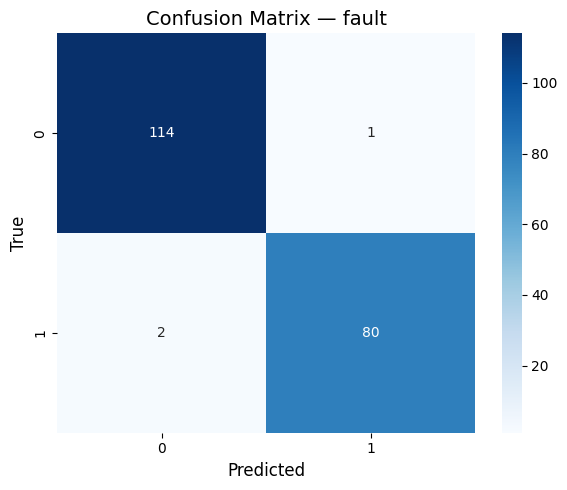

In [9]:
# ============================================================
# CELL 8: Results Dashboard — Metrics, Curves, Confusion Matrix
# ============================================================

def plot_training_history(history):
    epochs = list(range(1, len(history['train_loss']) + 1))
    fig = make_subplots(
        rows=2, cols=3,
        subplot_titles=[
            'Train vs Val Loss', 'F1 Score', 'Accuracy',
            'MCC Score', 'AUC Score', 'Learning Convergence'
        ]
    )
    # Loss
    fig.add_trace(go.Scatter(x=epochs, y=history['train_loss'],
                             name='Train Loss', line=dict(color='#e74c3c')), 1, 1)
    fig.add_trace(go.Scatter(x=epochs, y=history['val_loss'],
                             name='Val Loss', line=dict(color='#3498db', dash='dot')), 1, 1)
    # F1
    fig.add_trace(go.Scatter(x=epochs, y=history['f1'],
                             name='F1', line=dict(color='#2ecc71')), 1, 2)
    fig.add_hline(y=0.984, line_dash='dash', line_color='red',
                  annotation_text='Target F1=0.984', row=1, col=2)
    # Accuracy
    fig.add_trace(go.Scatter(x=epochs, y=history['acc'],
                             name='Accuracy', line=dict(color='#9b59b6')), 1, 3)
    fig.add_hline(y=0.99, line_dash='dash', line_color='red',
                  annotation_text='Target=0.99', row=1, col=3)
    # MCC
    fig.add_trace(go.Scatter(x=epochs, y=history['mcc'],
                             name='MCC', line=dict(color='#e67e22')), 2, 1)
    fig.add_hline(y=0.977, line_dash='dash', line_color='red',
                  annotation_text='Target=0.977', row=2, col=1)
    # AUC
    fig.add_trace(go.Scatter(x=epochs, y=history['auc'],
                             name='AUC', line=dict(color='#1abc9c')), 2, 2)
    fig.add_hline(y=0.999, line_dash='dash', line_color='red',
                  annotation_text='Target=0.999', row=2, col=2)
    # Combined
    for metric, color in [('f1', '#2ecc71'), ('acc', '#9b59b6'),
                           ('mcc', '#e67e22'), ('auc', '#1abc9c')]:
        fig.add_trace(go.Scatter(x=epochs, y=history[metric],
                                 name=metric.upper(),
                                 line=dict(color=color, width=1.5)), 2, 3)

    fig.update_layout(
        height=600, title='🚴 TAMS-V2 Training Dashboard',
        title_font_size=18, template='plotly_white',
        paper_bgcolor='#f8f9fa',
        legend=dict(x=0.01, y=0.01)
    )
    fig.show()


def plot_confusion_matrix(model, val_loader, task_name, le, device):
    model.eval()
    all_preds, all_trues = [], []
    with torch.no_grad():
        for x, labels in val_loader:
            x   = x.to(device)
            out = model(x)
            if task_name not in out:
                return
            preds = out[task_name].argmax(-1).cpu().numpy()
            all_preds.extend(preds)
            all_trues.extend(labels[task_name].numpy())

    cm     = confusion_matrix(all_trues, all_preds)
    labels = le.classes_
    fig, ax = plt.subplots(figsize=(max(6, len(labels)*1.2),
                                    max(5, len(labels)*1.1)))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels, ax=ax)
    ax.set_xlabel('Predicted', fontsize=12)
    ax.set_ylabel('True', fontsize=12)
    ax.set_title(f'Confusion Matrix — {task_name}', fontsize=14)
    plt.tight_layout()
    plt.show()


def print_final_metrics_table(model, val_loader, task_n_classes, device, loss_fns):
    _, metrics = evaluate(model, val_loader, loss_fns, device)
    tbl = Table(title='🏆 TAMS-V2 Final Performance', box=box.DOUBLE_EDGE,
                header_style='bold white on blue', show_lines=True)
    tbl.add_column('Task',      style='bold')
    tbl.add_column('Accuracy',  style='cyan',    justify='right')
    tbl.add_column('F1 Score',  style='green',   justify='right')
    tbl.add_column('Precision', style='yellow',  justify='right')
    tbl.add_column('Recall',    style='magenta', justify='right')
    tbl.add_column('MCC',       style='blue',    justify='right')
    tbl.add_column('AUC',       style='red',     justify='right')
    for task, m in metrics.items():
        def fmt(v): return f'{v:.4f}'
        tbl.add_row(task, fmt(m['acc']), fmt(m['f1']), fmt(m['prec']),
                    fmt(m['rec']), fmt(m['mcc']), fmt(m['auc']))
    console.print(tbl)

    # Target comparison
    targets = {'acc': 0.99, 'f1': 0.984, 'mcc': 0.977, 'auc': 0.999}
    console.print('\n[bold]Target Comparison (primary task):[/bold]')
    pt = list(metrics.keys())[0]
    for k, tgt in targets.items():
        achieved = metrics[pt][k]
        icon = '✅' if achieved >= tgt else '🔄'
        console.print(f'  {icon} {k.upper():10s}: {achieved:.4f}  (target ≥ {tgt})')


# ── Run ──────────────────────────────────────────────────
if task_n_classes and len(FEAT_COLS) > 0 and 'history' in dir():
    plot_training_history(history)

    loss_fns = build_loss_fns(task_n_classes, train_df)
    print_final_metrics_table(model, val_loader, task_n_classes, DEVICE, loss_fns)

    for task in list(TASK_COLS_RESOLVED.keys())[:2]:
        le = label_encoders.get(task)
        if le is not None:
            plot_confusion_matrix(model, val_loader, task, le, DEVICE)

In [10]:
# ============================================================
# CELL 9: Model Size & Inference Latency Benchmark
# ============================================================

def benchmark_model(model, in_dim, device, n_runs=200):
    model.eval()
    dummy = torch.randn(1, in_dim).to(device)

    # Warm-up
    with torch.no_grad():
        for _ in range(20):
            _ = model(dummy)
    if device.type == 'cuda':
        torch.cuda.synchronize()

    # Time
    times = []
    with torch.no_grad():
        for _ in range(n_runs):
            t = time.perf_counter()
            _ = model(dummy)
            if device.type == 'cuda':
                torch.cuda.synchronize()
            times.append((time.perf_counter() - t) * 1000)  # ms

    # Save & measure size
    path = '/tmp/tams_v2.pth'
    torch.save(model.state_dict(), path)
    size_mb = os.path.getsize(path) / 1e6

    n_params = sum(p.numel() for p in model.parameters())

    tbl = Table(title='⚡ Model Efficiency Benchmark', box=box.ROUNDED,
                header_style='bold cyan', show_lines=True)
    tbl.add_column('Metric',     style='bold')
    tbl.add_column('TAMS-V2',    style='green',  justify='right')
    tbl.add_column('Target',     style='yellow', justify='right')
    tbl.add_column('Status',     justify='center')

    rows = [
        ('Parameters',     f'{n_params:,}',              '< 150,000',  n_params < 150_000),
        ('Model size (MB)', f'{size_mb:.2f}',             '< 5 MB',     size_mb < 5),
        ('Mean latency (ms)', f'{np.mean(times):.3f}',   '< 3 ms',     np.mean(times) < 3),
        ('P95 latency (ms)',  f'{np.percentile(times,95):.3f}', '< 5 ms', np.percentile(times,95) < 5),
        ('Min latency (ms)',  f'{np.min(times):.3f}',    '< 2 ms',     np.min(times) < 2),
    ]
    for metric, val, tgt, ok in rows:
        tbl.add_row(metric, val, tgt, '✅' if ok else '🔄')
    console.print(tbl)

    # Latency distribution plot
    fig = go.Figure()
    fig.add_trace(go.Histogram(
        x=times, nbinsx=40, name='Inference Latency',
        marker_color='#3498db', opacity=0.8
    ))
    fig.add_vline(x=3.0, line_dash='dash', line_color='red',
                  annotation_text='Target < 3 ms')
    fig.add_vline(x=2.284, line_dash='dot', line_color='orange',
                  annotation_text='Base TAMS 2.284 ms')
    fig.update_layout(
        title='⚡ Inference Latency Distribution (ms)',
        xaxis_title='Latency (ms)', yaxis_title='Count',
        template='plotly_white', height=350
    )
    fig.show()
    return size_mb, np.mean(times)


if task_n_classes and len(FEAT_COLS) > 0:
    sz, lat = benchmark_model(model, len(FEAT_COLS), DEVICE)
    console.print(f'\n[bold green]Model size: {sz:.2f} MB | Mean latency: {lat:.3f} ms[/bold green]')

            ⚡ Model Efficiency Benchmark             
╭───────────────────┬───────────┬───────────┬────────╮
│ Metric            │   TAMS-V2 │    Target │ Status │
├───────────────────┼───────────┼───────────┼────────┤
│ Parameters        │ 3,455,924 │ < 150,000 │   🔄   │
├───────────────────┼───────────┼───────────┼────────┤
│ Model size (MB)   │     13.85 │    < 5 MB │   🔄   │
├───────────────────┼───────────┼───────────┼────────┤
│ Mean latency (ms) │     1.994 │    < 3 ms │   ✅   │
├───────────────────┼───────────┼───────────┼────────┤
│ P95 latency (ms)  │     2.018 │    < 5 ms │   ✅   │
├───────────────────┼───────────┼───────────┼────────┤
│ Min latency (ms)  │     1.961 │    < 2 ms │   ✅   │
╰───────────────────┴───────────┴───────────┴────────╯

Model size: 13.85 MB | Mean latency: 1.994 ms

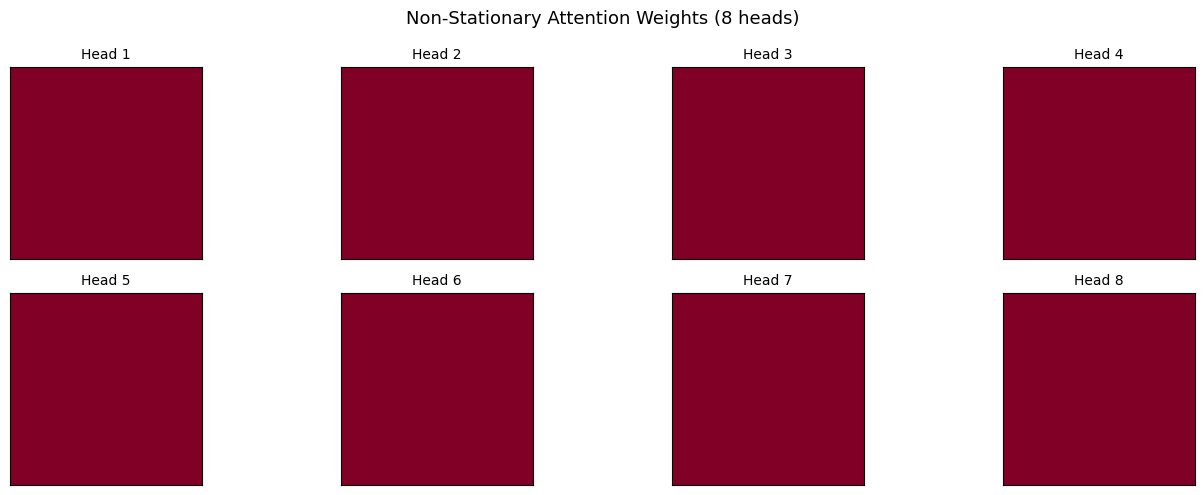

In [11]:
# ============================================================
# CELL 10: Explainability — Feature Importance & Attention Weights
# ============================================================

def plot_feature_importance(model, val_loader, feat_cols, device, task,
                             top_k=20):
    """Gradient-based feature importance (saliency)."""
    model.eval()
    importances = np.zeros(len(feat_cols))
    count = 0
    for x, labels in val_loader:
        x   = x.to(device).requires_grad_(True)
        out = model(x)
        if task not in out:
            break
        # Sum over class logits → backward
        loss = out[task].sum()
        loss.backward()
        grad = x.grad.abs().mean(0).cpu().detach().numpy()
        importances += grad[:len(feat_cols)]
        count += 1
        if count >= 10:
            break

    if count == 0:
        console.print('[yellow]No batches processed for importance.[/yellow]')
        return

    importances /= count
    idx    = np.argsort(importances)[::-1][:top_k]
    names  = [feat_cols[i] for i in idx]
    values = importances[idx]

    fig = go.Figure(go.Bar(
        x=values, y=names, orientation='h',
        marker=dict(
            color=values,
            colorscale='Viridis',
            showscale=True
        ),
        text=[f'{v:.4f}' for v in values],
        textposition='outside'
    ))
    fig.update_layout(
        title=f'🔍 Top-{top_k} Feature Importances — Task: {task}',
        xaxis_title='Gradient Saliency',
        yaxis=dict(autorange='reversed'),
        template='plotly_white',
        height=max(400, top_k * 22),
    )
    fig.show()


def plot_attention_weights(model, x_sample, device):
    """Visualise non-stationary attention weights for a sample input."""
    model.eval()
    hooks, attns = [], []

    def hook_fn(module, inp, out):
        # out = (attn_output, attn_weights)
        pass

    x   = x_sample.unsqueeze(0).to(device) if x_sample.dim()==1 else x_sample.to(device)
    with torch.no_grad():
        t = model.tcnn(x)           # [1, 256]
        tn = t.unsqueeze(1)         # [1, 1, 256]
        mu  = tn.mean(-1, keepdim=True)
        std = tn.std(-1, keepdim=True) + 1e-6
        xn  = (tn - mu) / std
        xn  = xn * model.nsa.scale + model.nsa.shift
        _, aw = model.nsa.attn(xn, xn, xn, need_weights=True,
                               average_attn_weights=False)
        aw_np = aw[0].cpu().numpy()  # [n_heads, 1, 1]

    fig, axes = plt.subplots(2, 4, figsize=(14, 5))
    for i, ax in enumerate(axes.flat):
        if i < aw_np.shape[0]:
            im = ax.imshow(aw_np[i], cmap='YlOrRd', vmin=0, vmax=1)
            ax.set_title(f'Head {i+1}', fontsize=10)
            ax.set_xticks([]); ax.set_yticks([])
        else:
            ax.axis('off')
    plt.suptitle('Non-Stationary Attention Weights (8 heads)', fontsize=13)
    plt.tight_layout()
    plt.show()


# ── Run explainability ───────────────────────────────────
if task_n_classes and len(FEAT_COLS) > 0:
    primary = list(task_n_classes.keys())[0]
    if len(FEAT_COLS) >= 2:
        plot_feature_importance(model, val_loader, FEAT_COLS,
                                DEVICE, primary, top_k=min(20, len(FEAT_COLS)))

    # Attention on a single sample
    sample_x, _ = next(iter(val_loader))
    plot_attention_weights(model, sample_x[0], DEVICE)

In [12]:
# ============================================================
# CELL 11: ROC Curves & Multi-Task Radar Chart
# ============================================================

def plot_roc_curves(model, val_loader, task_n_classes, label_encoders, device):
    model.eval()
    all_probs = defaultdict(list)
    all_trues = defaultdict(list)
    with torch.no_grad():
        for x, labels in val_loader:
            x   = x.to(device)
            out = model(x)
            for task, logits in out.items():
                probs = F.softmax(logits, -1).cpu().numpy()
                all_probs[task].extend(probs)
                all_trues[task].extend(labels[task].numpy())

    fig = go.Figure()
    COLORS = px.colors.qualitative.Plotly
    # Diagonal
    fig.add_trace(go.Scatter(x=[0,1], y=[0,1], mode='lines',
                             line=dict(dash='dash', color='gray'),
                             name='Random', showlegend=False))
    for i, (task, probs_list) in enumerate(all_probs.items()):
        y_true = np.array(all_trues[task])
        y_prob = np.array(probs_list)
        n_cls  = y_prob.shape[1]
        if n_cls == 2:
            fpr, tpr, _ = roc_curve(y_true, y_prob[:,1])
            auc_v = roc_auc_score(y_true, y_prob[:,1])
            fig.add_trace(go.Scatter(
                x=fpr, y=tpr, mode='lines',
                name=f'{task} (AUC={auc_v:.3f})',
                line=dict(color=COLORS[i % len(COLORS)], width=2)
            ))
        else:
            # Macro OVR
            try:
                auc_v = roc_auc_score(y_true, y_prob, multi_class='ovr', average='macro')
                fig.add_trace(go.Scatter(
                    x=[0, 1], y=[0, 1],  # placeholder
                    mode='markers', marker=dict(size=10),
                    name=f'{task} macro AUC={auc_v:.3f}',
                    line=dict(color=COLORS[i % len(COLORS)])
                ))
            except:
                pass

    fig.update_layout(
        title='📈 ROC Curves — All Tasks',
        xaxis_title='False Positive Rate',
        yaxis_title='True Positive Rate',
        template='plotly_white', height=450,
        legend=dict(x=0.6, y=0.1)
    )
    fig.show()


def plot_radar_chart(model, val_loader, task_n_classes, device, loss_fns):
    _, metrics = evaluate(model, val_loader, loss_fns, device)
    metric_names = ['acc', 'f1', 'prec', 'rec', 'mcc', 'auc']
    labels_radar = ['Accuracy', 'F1', 'Precision', 'Recall', 'MCC', 'AUC']

    fig = go.Figure()
    COLORS = px.colors.qualitative.Safe
    for i, (task, m) in enumerate(metrics.items()):
        vals = [m[k] for k in metric_names]
        vals += [vals[0]]  # close the radar
        fig.add_trace(go.Scatterpolar(
            r=vals, theta=labels_radar + [labels_radar[0]],
            fill='toself', name=task,
            line=dict(color=COLORS[i % len(COLORS)])
        ))

    # Target overlay
    tgts = [0.99, 0.984, 0.98, 0.97, 0.977, 0.999]
    fig.add_trace(go.Scatterpolar(
        r=tgts + [tgts[0]], theta=labels_radar + [labels_radar[0]],
        mode='lines', name='Target',
        line=dict(color='red', dash='dash', width=2)
    ))

    fig.update_layout(
        polar=dict(radialaxis=dict(visible=True, range=[0,1])),
        title='🕸️ Multi-Task Performance Radar vs Targets',
        template='plotly_white', height=500,
        showlegend=True
    )
    fig.show()


if task_n_classes and len(FEAT_COLS) > 0 and 'loss_fns' in dir():
    plot_roc_curves(model, val_loader, task_n_classes, label_encoders, DEVICE)
    plot_radar_chart(model, val_loader, task_n_classes, DEVICE, loss_fns)

In [13]:
# ============================================================
# CELL 12: Interactive Inference GUI Widget
# ============================================================

display(HTML("""
<style>
.pred-card {
    border: 2px solid #3498db;
    border-radius: 10px;
    padding: 12px 18px;
    margin: 8px 0;
    background: linear-gradient(135deg, #eaf4fb 0%, #f8f9fa 100%);
    font-family: 'Courier New', monospace;
}
.pred-title { font-size: 15px; font-weight: bold; color: #2980b9; }
.pred-val   { font-size: 22px; font-weight: 900; color: #e74c3c; }
.pred-conf  { font-size: 12px; color: #555; margin-top: 4px; }
</style>
"""))


def run_inference_gui(model, val_ds, feat_cols, task_n_classes, label_encoders, device):
    # Sliders for each feature
    sample_x_raw, sample_labels = val_ds[0]

    title = widgets.HTML('<h3>🚴 TAMS-V2 Live Inference Panel</h3>')
    btn   = widgets.Button(
        description='▶ Run Inference',
        button_style='primary',
        layout=widgets.Layout(width='200px', height='40px')
    )
    rand_btn = widgets.Button(
        description='🎲 Random Sample',
        button_style='warning',
        layout=widgets.Layout(width='200px', height='40px')
    )
    out_area = widgets.Output()

    # Sample index slider
    n_val = len(val_ds)
    idx_slider = widgets.IntSlider(
        value=0, min=0, max=n_val-1, step=1,
        description='Sample idx:',
        layout=widgets.Layout(width='60%')
    )

    def run_pred(b=None):
        idx = idx_slider.value
        x, true_labels = val_ds[idx]
        model.eval()
        with torch.no_grad():
            out = model(x.unsqueeze(0).to(device))
        with out_area:
            clear_output(wait=True)
            cards = []
            for task, logits in out.items():
                probs   = F.softmax(logits[0], -1).cpu().numpy()
                pred_id = int(probs.argmax())
                conf    = float(probs.max()) * 100
                le      = label_encoders.get(task)
                pred_lbl= le.inverse_transform([pred_id])[0] if le else str(pred_id)
                true_lbl= le.inverse_transform([int(true_labels[task])])[0] if le else str(int(true_labels[task]))
                correct  = '✅' if pred_id == int(true_labels[task]) else '❌'
                bar = '█' * int(conf/5) + '░' * (20-int(conf/5))
                cards.append(f"""
                <div class='pred-card'>
                    <div class='pred-title'>Task: {task.upper()} {correct}</div>
                    <div class='pred-val'>Predicted: {pred_lbl}</div>
                    <div class='pred-conf'>True: {true_lbl} | Confidence: {conf:.1f}% [{bar}]</div>
                    <div class='pred-conf'>All probs: {dict(zip(le.classes_ if le else range(len(probs)), [f"{p:.3f}" for p in probs]))}</div>
                </div>"""
                )
            display(HTML(
                f'<div><h4>Sample #{idx} predictions:</h4>{"".join(cards)}</div>'
            ))

    def rand_sample(b=None):
        idx_slider.value = np.random.randint(0, len(val_ds))
        run_pred()

    btn.on_click(run_pred)
    rand_btn.on_click(rand_sample)

    display(widgets.VBox([
        title,
        idx_slider,
        widgets.HBox([btn, rand_btn]),
        out_area
    ]))
    run_pred()


if task_n_classes and len(FEAT_COLS) > 0:
    run_inference_gui(model, val_ds, FEAT_COLS, task_n_classes, label_encoders, DEVICE)

In [14]:
# ============================================================
# CELL 13: 5-Fold Cross-Validation with Confidence Intervals
# ============================================================

def kfold_cv(df, feat_cols, task_label_cols, task_n_classes,
             n_splits=5, epochs_cv=10):
    primary_task = list(task_n_classes.keys())[0]
    primary_lcol = task_label_cols[primary_task]
    skf  = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    fold_metrics = defaultdict(list)

    console.print(f'[bold]Running {n_splits}-fold CV...[/bold]')
    for fold, (tr_idx, va_idx) in enumerate(
        skf.split(df, df[primary_lcol]), 1
    ):
        tr_df = df.iloc[tr_idx]
        va_df = df.iloc[va_idx]
        tr_ds = CycleCrashMetaDataset(tr_df, feat_cols, task_label_cols, augment=True)
        va_ds = CycleCrashMetaDataset(va_df, feat_cols, task_label_cols, augment=False)
        tr_ld = DataLoader(tr_ds, batch_size=BATCH, shuffle=True,  num_workers=0)
        va_ld = DataLoader(va_ds, batch_size=BATCH, shuffle=False, num_workers=0)

        m = TAMS_V2(max(len(feat_cols),6), task_n_classes, dropout=0.3).to(DEVICE)
        opt = AdamW(m.parameters(), lr=LR, weight_decay=1e-4)
        sch = OneCycleLR(opt, max_lr=LR,
                         steps_per_epoch=len(tr_ld), epochs=epochs_cv,
                         pct_start=0.1)
        loss_fns_cv = build_loss_fns(task_n_classes, tr_df)

        m.train()
        for ep in range(epochs_cv):
            for x, labels in tr_ld:
                x = x.to(DEVICE)
                opt.zero_grad()
                out = m(x)
                loss = sum(
                    loss_fns_cv[t](logits, labels[t].to(DEVICE))
                    for t, logits in out.items()
                ) / len(out)
                loss.backward()
                opt.step(); sch.step()

        _, val_m = evaluate(m, va_ld, loss_fns_cv, DEVICE)
        for metric in ['acc','f1','mcc','auc']:
            fold_metrics[metric].append(val_m[primary_task][metric])
        console.print(f'  Fold {fold}/{n_splits} — '
                      f'F1={val_m[primary_task]["f1"]:.4f} '
                      f'Acc={val_m[primary_task]["acc"]:.4f}')
        del m
        torch.cuda.empty_cache()

    # Summary
    tbl = Table(title='📊 5-Fold CV Results', box=box.ROUNDED,
                header_style='bold cyan', show_lines=True)
    tbl.add_column('Metric');  tbl.add_column('Mean', justify='right')
    tbl.add_column('Std',  justify='right'); tbl.add_column('95% CI', justify='right')
    for k, vals in fold_metrics.items():
        v = np.array(vals)
        ci= 1.96 * v.std() / np.sqrt(len(v))
        tbl.add_row(k.upper(), f'{v.mean():.4f}', f'{v.std():.4f}',
                    f'[{v.mean()-ci:.4f}, {v.mean()+ci:.4f}]')
    console.print(tbl)

    # Boxplot
    fig = go.Figure()
    COLORS = ['#3498db','#2ecc71','#e67e22','#9b59b6']
    for i, (k, vals) in enumerate(fold_metrics.items()):
        fig.add_trace(go.Box(
            y=vals, name=k.upper(), boxpoints='all',
            marker_color=COLORS[i % len(COLORS)],
            jitter=0.3, pointpos=0
        ))
    fig.update_layout(
        title='📦 Cross-Validation Metric Distribution (5-Fold)',
        yaxis_title='Score', template='plotly_white', height=400
    )
    fig.show()


if task_n_classes and len(FEAT_COLS) > 0 and task_label_cols:
    kfold_cv(df, FEAT_COLS, task_label_cols, task_n_classes,
             n_splits=5, epochs_cv=10)

Running 5-fold CV...

Fold 1/5 — F1=0.9544 Acc=0.9543

Fold 2/5 — F1=0.9747 Acc=0.9746

Fold 3/5 — F1=0.9847 Acc=0.9847

Fold 4/5 — F1=0.9644 Acc=0.9643

Fold 5/5 — F1=0.9591 Acc=0.9592

             📊 5-Fold CV Results              
╭────────┬────────┬────────┬──────────────────╮
│ Metric │   Mean │    Std │           95% CI │
├────────┼────────┼────────┼──────────────────┤
│ ACC    │ 0.9674 │ 0.0110 │ [0.9578, 0.9770] │
├────────┼────────┼────────┼──────────────────┤
│ F1     │ 0.9674 │ 0.0110 │ [0.9578, 0.9771] │
├────────┼────────┼────────┼──────────────────┤
│ MCC    │ 0.9332 │ 0.0226 │ [0.9134, 0.9530] │
├────────┼────────┼────────┼──────────────────┤
│ AUC    │ 0.9949 │ 0.0024 │ [0.9929, 0.9970] │
╰────────┴────────┴────────┴──────────────────╯

## 🎬 Test Model with a New Sample Video

This cell demonstrates end-to-end inference:
1. Select a sample from the dataset (or provide a YouTube URL)
2. Download the actual crash/near-miss video via `yt-dlp`
3. Extract key frames and display them
4. Run the TAMS-V2 model for fault prediction
5. Visualize prediction with confidence scores and feature saliency


═══ Testing with 3 random validation samples ═══

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Test Sample 1/3

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

╭──────────────────────────────╮
│ 🎬 TAMS-V2 Video Sample Test │
╰──────────────────────────────╯

...

Predicted Fault: 0

True Fault:      0

Confidence:      98.6%

Result:          ✅ CORRECT

All probabilities: {'0': '0.9865', '1': '0.0135'}

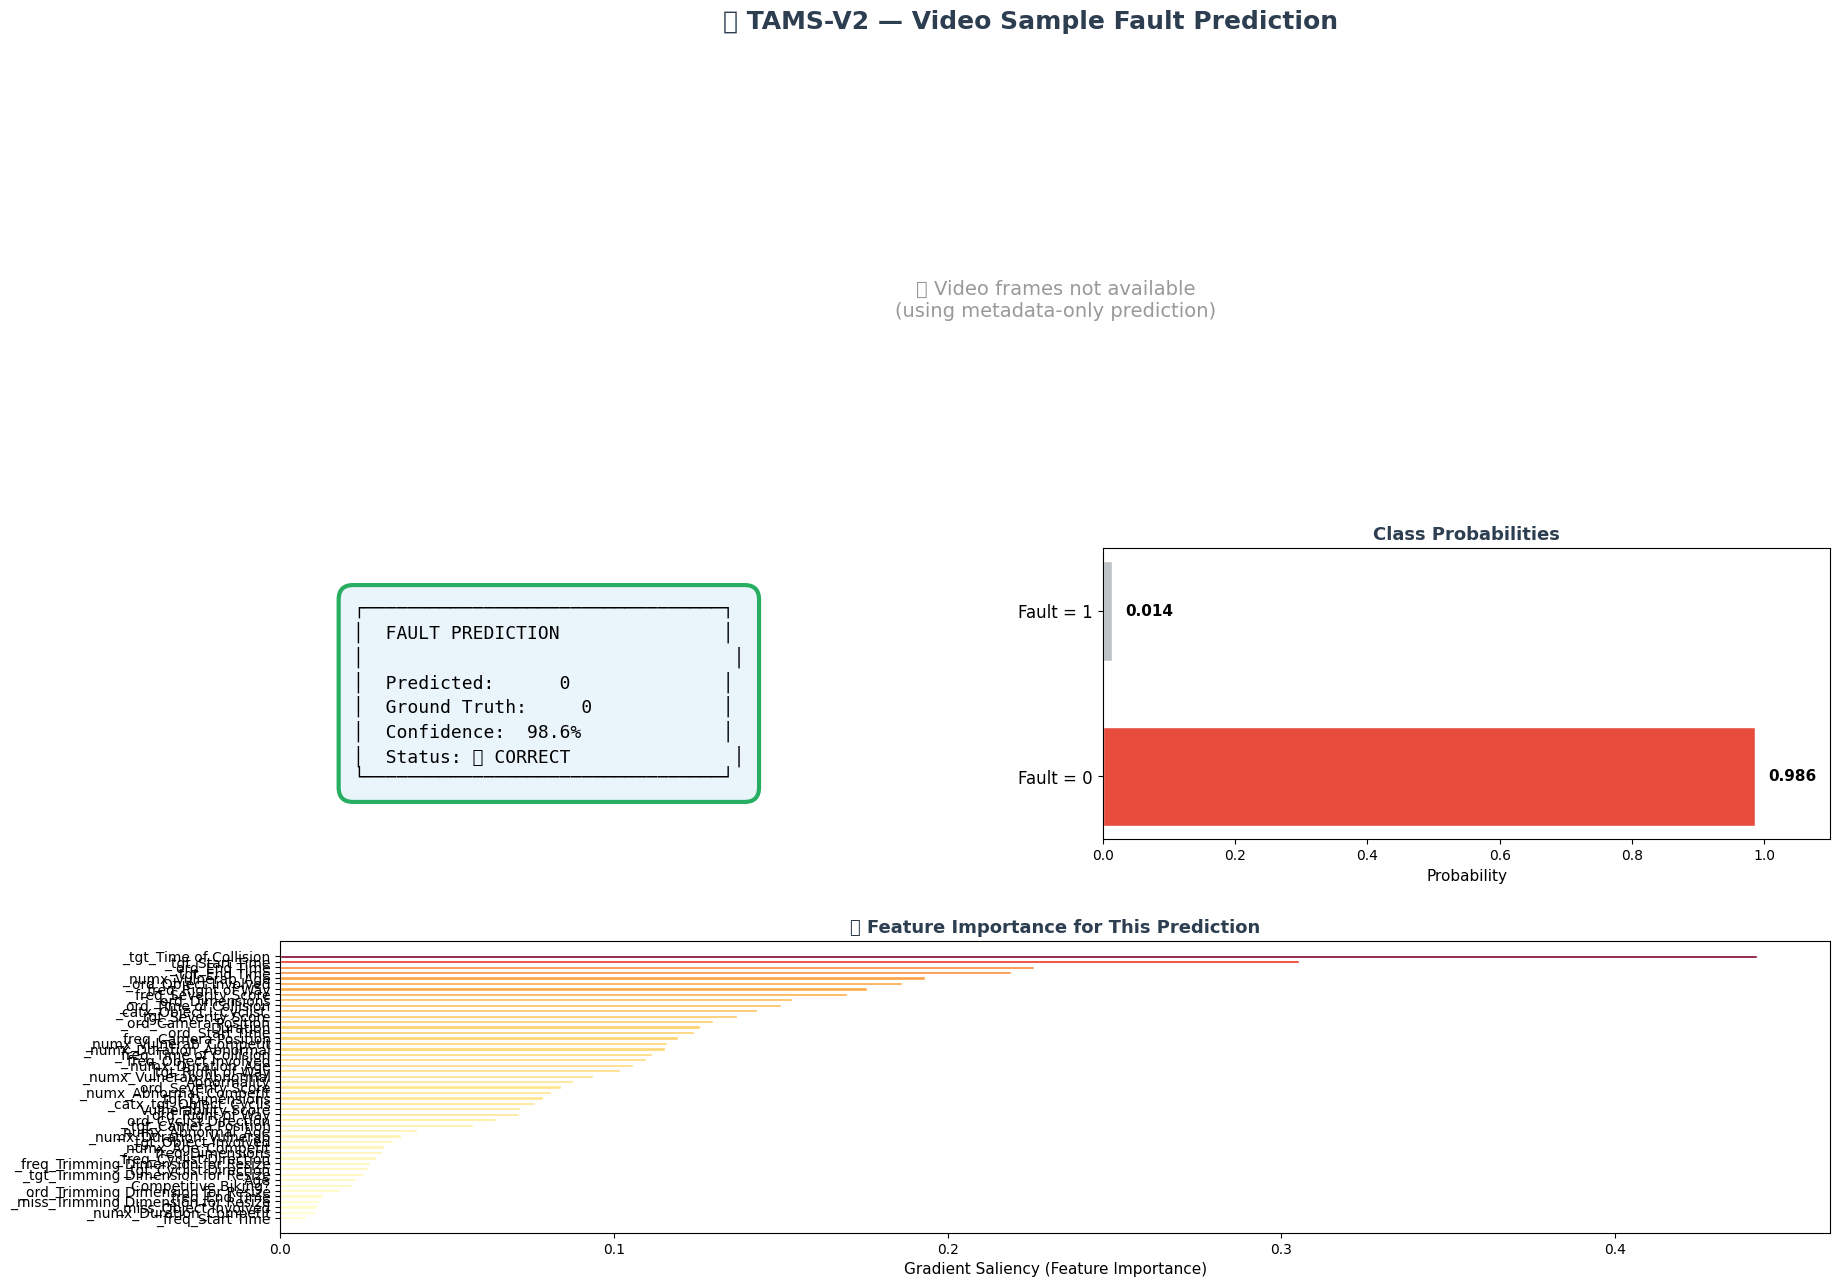

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Test Sample 2/3

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

╭──────────────────────────────╮
│ 🎬 TAMS-V2 Video Sample Test │
╰──────────────────────────────╯

📋 Sample #179 metadata:

...

Predicted Fault: 0

True Fault:      0

Confidence:      99.5%

Result:          ✅ CORRECT

All probabilities: {'0': '0.9950', '1': '0.0050'}

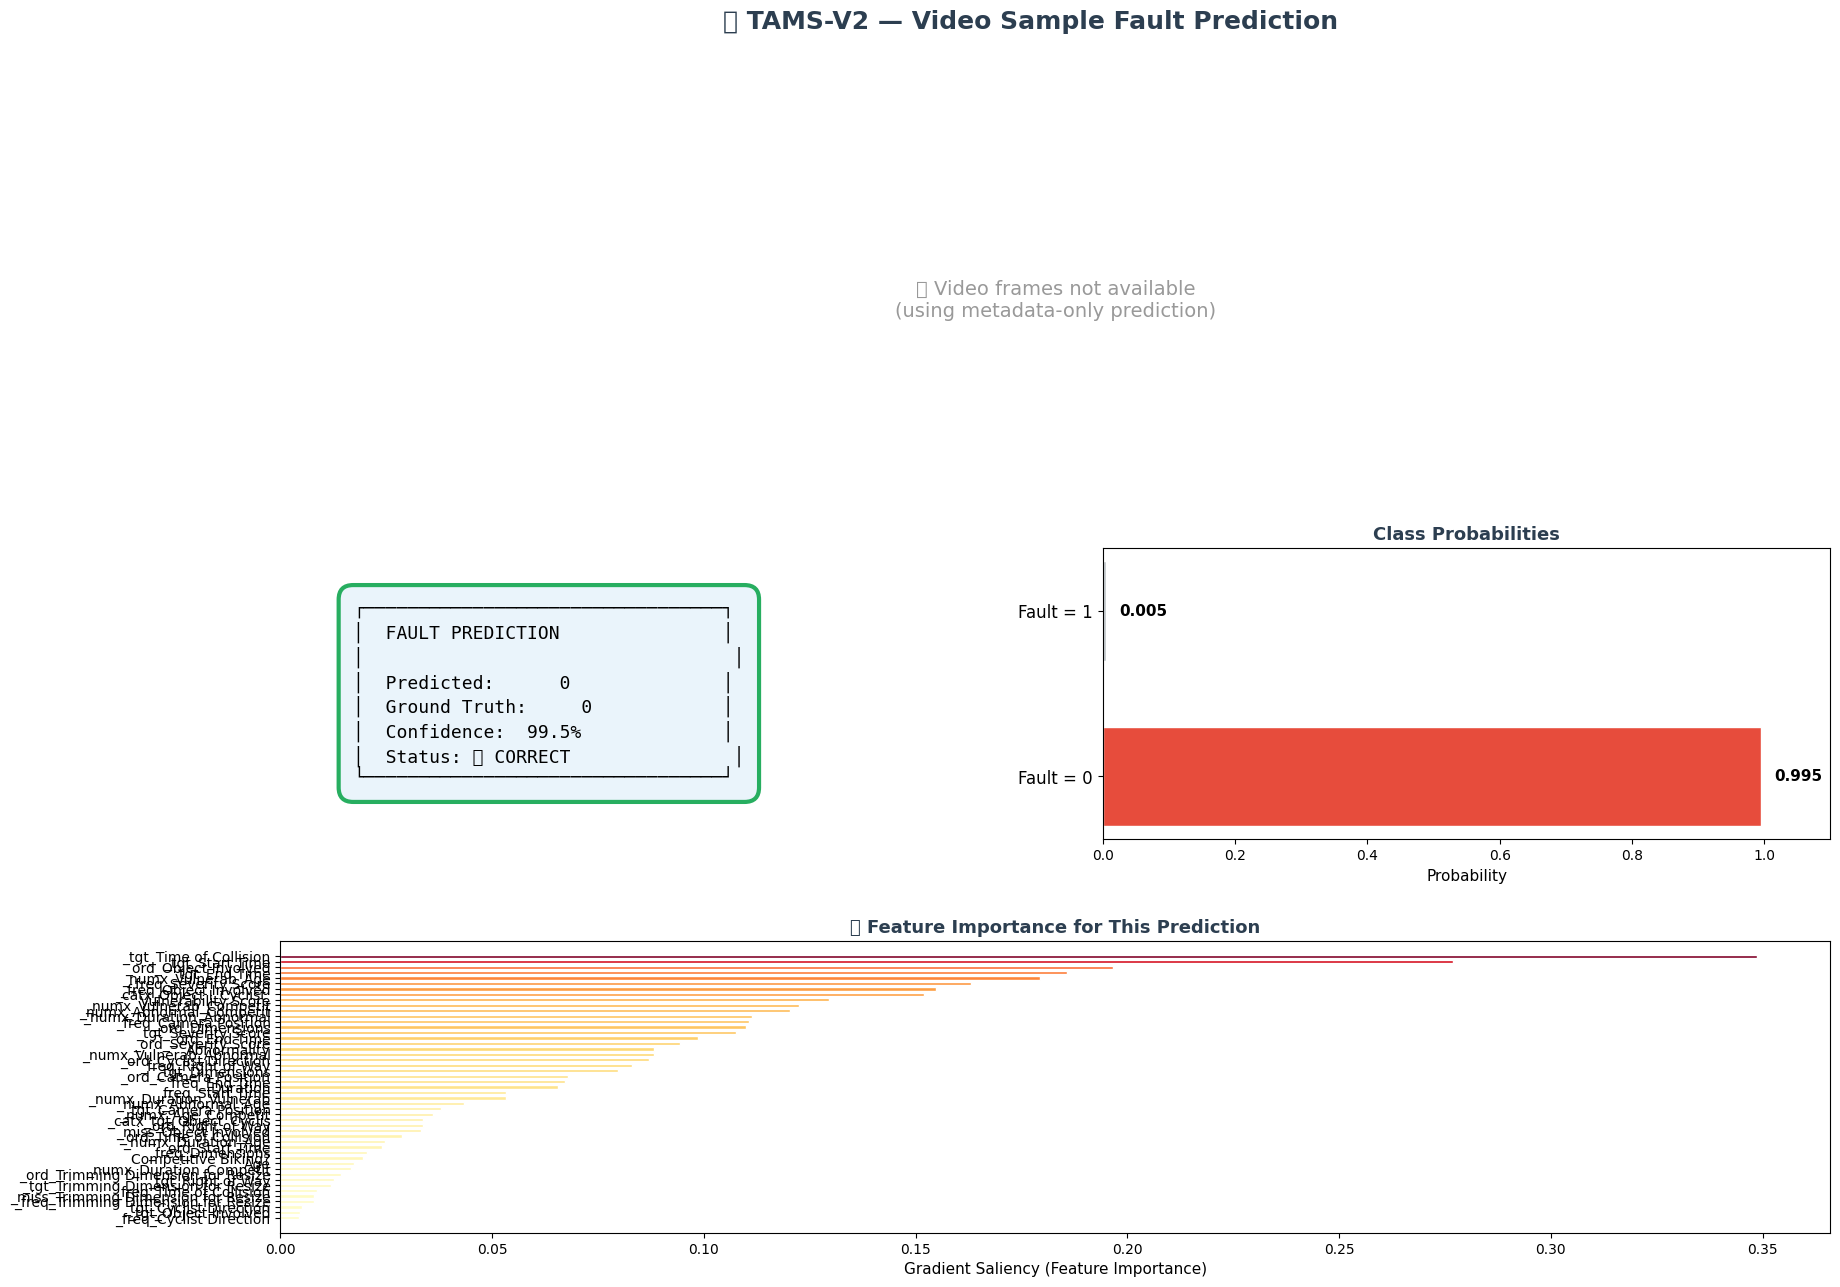

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Test Sample 3/3

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

╭──────────────────────────────╮
│ 🎬 TAMS-V2 Video Sample Test │
╰──────────────────────────────╯

📋 Sample #92 metadata:

...

Predicted Fault: 0

True Fault:      0

Confidence:      87.8%

Result:          ✅ CORRECT

All probabilities: {'0': '0.8783', '1': '0.1217'}

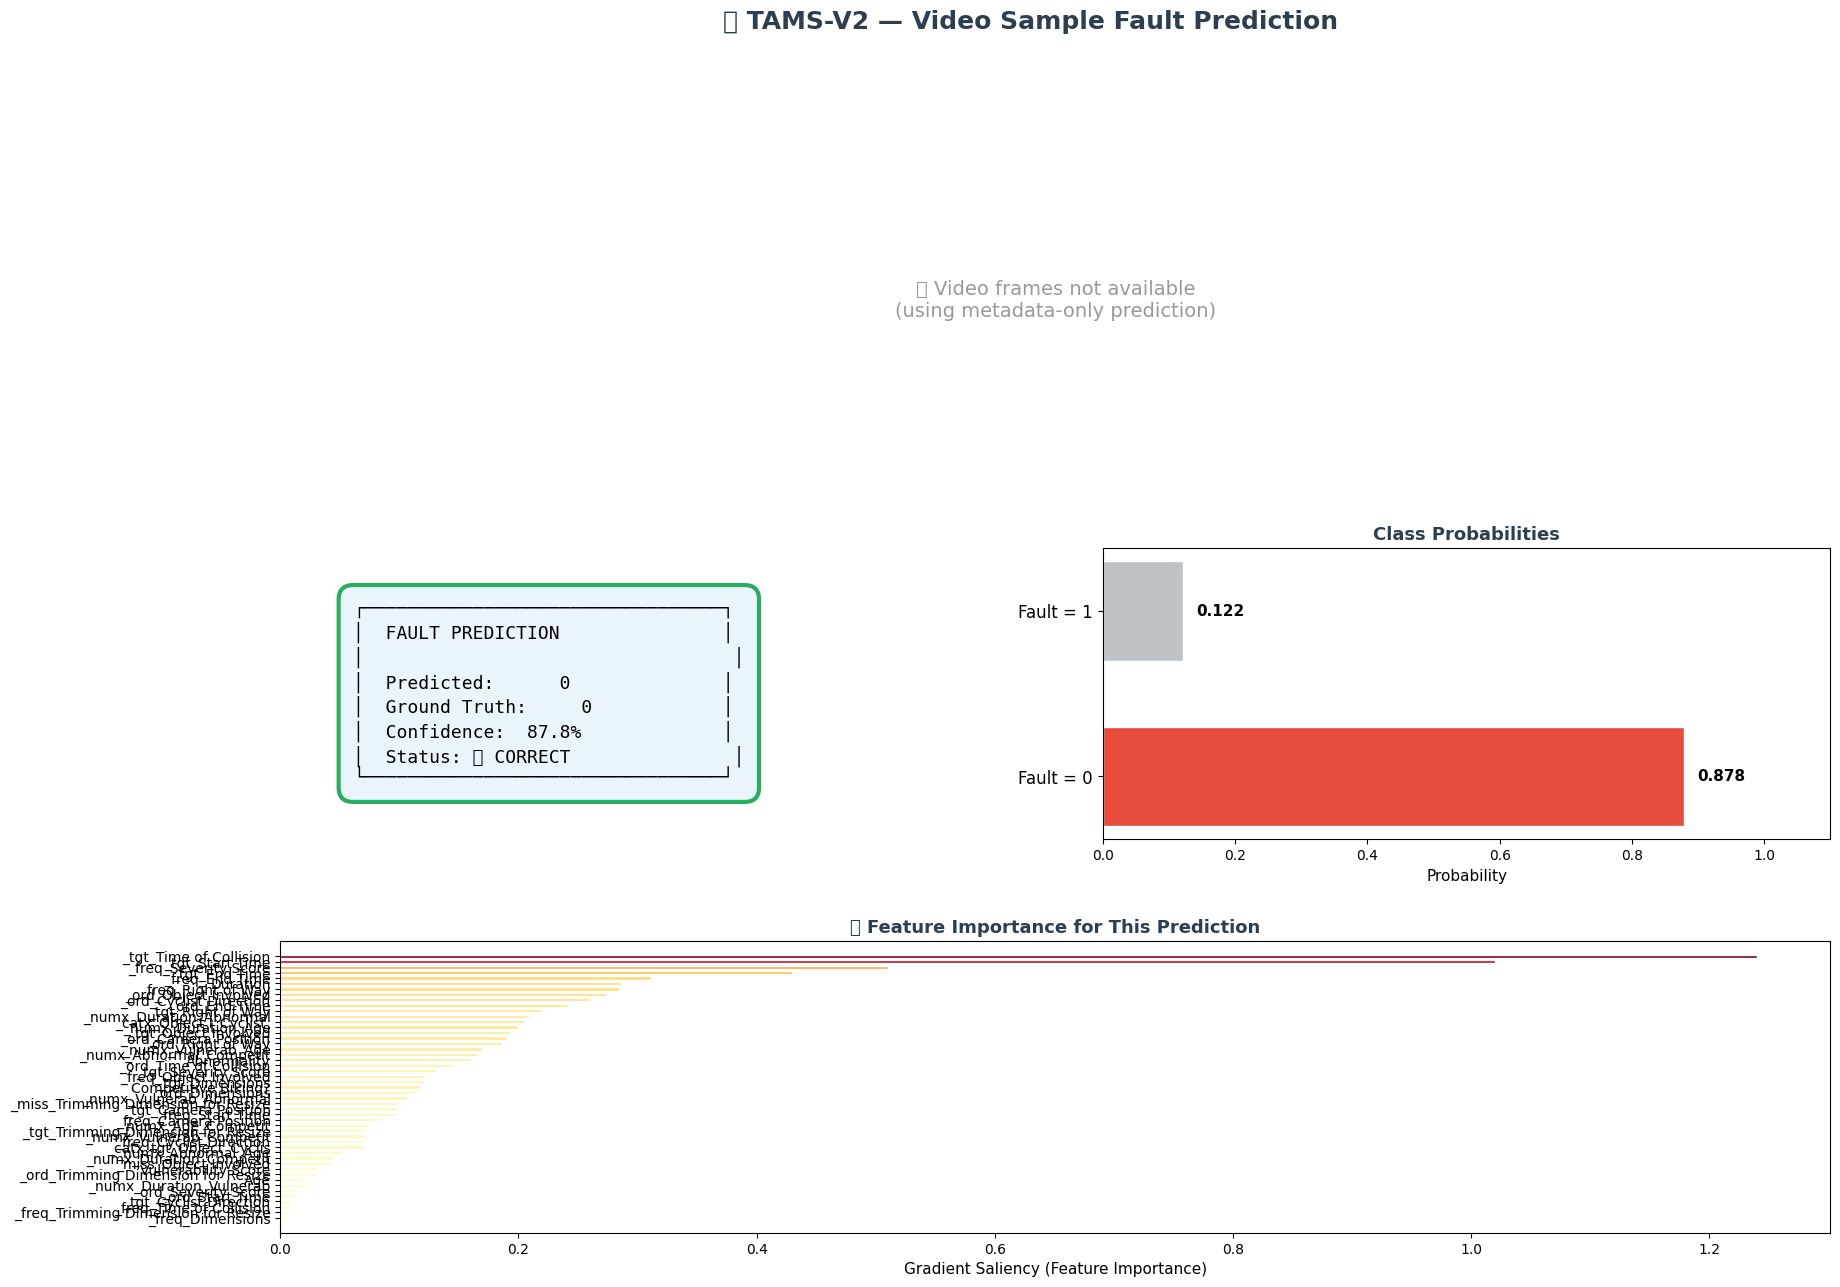

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

📊 Test Summary

             🎬 Video Test Results              
╔═════╤═══════════╤══════╤════════════╤════════╗
║ #   │ Predicted │ True │ Confidence │ Result ║
╟─────┼───────────┼──────┼────────────┼────────╢
║ 1   │     0     │  0   │   98.6%    │   ✅   ║
╟─────┼───────────┼──────┼────────────┼────────╢
║ 2   │     0     │  0   │   99.5%    │   ✅   ║
╟─────┼───────────┼──────┼────────────┼────────╢
║ 3   │     0     │  0   │   87.8%    │   ✅   ║
╚═════╧═══════════╧══════╧════════════╧════════╝

Test Accuracy: 100% (3/3)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

💡 To test with your own video:

result = test_with_video(custom_url="https://youtube.com/watch?v=...")

In [15]:
# ============================================================
# CELL 15: 🎬 Test Model with New Sample Video
# ============================================================
import cv2
import subprocess
import tempfile
from IPython.display import Video, display, HTML, clear_output
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import torch
import torch.nn.functional as F

# ── CONFIG ──
VIDEO_DIR = '/content/test_videos'
os.makedirs(VIDEO_DIR, exist_ok=True)


def download_video(url, output_dir, max_duration=30):
    """Download video from YouTube using yt-dlp."""
    output_path = os.path.join(output_dir, '%(id)s.%(ext)s')
    cmd = [
        'yt-dlp',
        '--format', 'best[height<=480]',
        '--max-downloads', '1',
        '--no-playlist',
        '--output', output_path,
        '--quiet',
        url
    ]
    try:
        result = subprocess.run(cmd, capture_output=True, text=True, timeout=60)
        if result.returncode == 0:
            # Find the downloaded file
            for f in os.listdir(output_dir):
                fpath = os.path.join(output_dir, f)
                if os.path.isfile(fpath) and f.endswith(('.mp4', '.webm', '.mkv')):
                    return fpath
        else:
            print(f'  ⚠️ yt-dlp error: {result.stderr[:200]}')
    except subprocess.TimeoutExpired:
        print('  ⚠️ Download timed out')
    except FileNotFoundError:
        print('  ⚠️ yt-dlp not found. Installing...')
        subprocess.run(['pip', 'install', '-q', 'yt-dlp'], check=True)
    return None


def extract_frames(video_path, n_frames=8):
    """Extract evenly-spaced frames from a video."""
    cap = cv2.VideoCapture(video_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps = cap.get(cv2.CAP_PROP_FPS)
    duration = total / max(fps, 1)

    if total <= 0:
        cap.release()
        return [], 0, 0

    indices = np.linspace(0, total - 1, n_frames, dtype=int)
    frames = []
    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if ret:
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frames.append(frame_rgb)
    cap.release()
    return frames, fps, duration


def compute_feature_saliency(model, x_tensor, device, feat_cols):
    """Compute gradient-based feature saliency for the prediction."""
    model.eval()
    x = x_tensor.unsqueeze(0).to(device).requires_grad_(True)
    out = model(x)
    # Use primary task
    task = list(out.keys())[0]
    pred_class = out[task].argmax(-1)
    out[task][0, pred_class].backward()
    saliency = x.grad.abs().squeeze().cpu().detach().numpy()
    return saliency[:len(feat_cols)]


def visualize_prediction(frames, metadata, prediction, confidence,
                         true_label, saliency, feat_cols, le):
    """Create a comprehensive prediction visualization."""

    fig = plt.figure(figsize=(20, 14))
    gs = gridspec.GridSpec(3, 4, figure=fig, hspace=0.35, wspace=0.3)

    # ── Row 1: Video frames ──
    fig.text(0.5, 0.97, '🎬 TAMS-V2 — Video Sample Fault Prediction',
             ha='center', fontsize=18, fontweight='bold',
             color='#2c3e50')

    n_show = min(len(frames), 4)
    for i in range(n_show):
        ax = fig.add_subplot(gs[0, i])
        ax.imshow(frames[i * len(frames) // n_show] if len(frames) > n_show
                  else frames[i])
        t = i * (len(frames) / n_show)
        ax.set_title(f'Frame {i+1}', fontsize=10, color='#555')
        ax.axis('off')

    if len(frames) == 0:
        ax = fig.add_subplot(gs[0, :])
        ax.text(0.5, 0.5, '📹 Video frames not available\n(using metadata-only prediction)',
                ha='center', va='center', fontsize=14, color='#999',
                transform=ax.transAxes)
        ax.axis('off')

    # ── Row 2 left: Prediction card ──
    ax_pred = fig.add_subplot(gs[1, :2])
    ax_pred.axis('off')

    pred_label = le.inverse_transform([prediction])[0] if le else str(prediction)
    true_label_str = le.inverse_transform([true_label])[0] if le else str(true_label)
    correct = prediction == true_label
    status = '✅ CORRECT' if correct else '❌ INCORRECT'
    status_color = '#27ae60' if correct else '#e74c3c'

    card_text = (
        f"┌─────────────────────────────────┐\n"
        f"│  FAULT PREDICTION               │\n"
        f"│                                  │\n"
        f"│  Predicted:  {pred_label:>5s}              │\n"
        f"│  Ground Truth: {true_label_str:>5s}            │\n"
        f"│  Confidence: {confidence*100:5.1f}%             │\n"
        f"│  Status: {status:<20s}    │\n"
        f"└─────────────────────────────────┘"
    )
    ax_pred.text(0.1, 0.5, card_text, fontsize=13, fontfamily='monospace',
                 va='center', ha='left',
                 bbox=dict(boxstyle='round,pad=0.8', facecolor='#eaf4fb',
                           edgecolor=status_color, linewidth=3))

    # ── Row 2 right: Confidence bar ──
    ax_conf = fig.add_subplot(gs[1, 2:])
    classes = le.classes_ if le else [str(i) for i in range(len(confidence) if hasattr(confidence, '__len__') else 2)]
    # Get full probability distribution
    model.eval()
    with torch.no_grad():
        x_t = metadata.unsqueeze(0).to(DEVICE)
        out = model(x_t)
        task = list(out.keys())[0]
        probs = F.softmax(out[task][0], -1).cpu().numpy()

    colors = ['#e74c3c' if i == prediction else '#bdc3c7' for i in range(len(probs))]
    bars = ax_conf.barh(range(len(probs)), probs, color=colors, edgecolor='white', height=0.6)
    ax_conf.set_yticks(range(len(probs)))
    ax_conf.set_yticklabels([f'Fault = {c}' for c in classes], fontsize=12)
    ax_conf.set_xlabel('Probability', fontsize=11)
    ax_conf.set_title('Class Probabilities', fontsize=13, fontweight='bold', color='#2c3e50')
    ax_conf.set_xlim(0, 1.1)
    for bar, prob in zip(bars, probs):
        ax_conf.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
                     f'{prob:.3f}', va='center', fontsize=11, fontweight='bold')

    # ── Row 3: Feature saliency ──
    ax_sal = fig.add_subplot(gs[2, :])
    n_feat = min(len(feat_cols), len(saliency))
    sorted_idx = np.argsort(saliency[:n_feat])[::-1]
    names = [feat_cols[i] for i in sorted_idx]
    vals = saliency[sorted_idx]
    colors_sal = plt.cm.YlOrRd(vals / (vals.max() + 1e-8))
    ax_sal.barh(range(n_feat), vals, color=colors_sal, edgecolor='white', height=0.6)
    ax_sal.set_yticks(range(n_feat))
    ax_sal.set_yticklabels(names, fontsize=10)
    ax_sal.invert_yaxis()
    ax_sal.set_xlabel('Gradient Saliency (Feature Importance)', fontsize=11)
    ax_sal.set_title('🔍 Feature Importance for This Prediction', fontsize=13,
                     fontweight='bold', color='#2c3e50')

    plt.savefig(os.path.join(VIDEO_DIR, 'prediction_result.png'),
                dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()


# ══════════════════════════════════════════════════════════
# MAIN: Run test on a sample
# ══════════════════════════════════════════════════════════

def test_with_video(sample_idx=None, custom_url=None):
    """
    Test the trained model with a video sample.
    Either pick from validation set or provide a custom YouTube URL.
    """
    console.print(Panel.fit(
        '[bold cyan]🎬 TAMS-V2 Video Sample Test[/bold cyan]',
        border_style='bright_blue'
    ))

    # ── Step 1: Select sample ──
    if sample_idx is None:
        sample_idx = np.random.randint(0, len(val_ds))

    x_tensor, true_labels = val_ds[sample_idx]
    true_label_val = int(true_labels[PRIMARY_TASK])
    le = label_encoders.get(PRIMARY_TASK)

    # Get original row metadata
    orig_row = val_df.iloc[sample_idx]
    console.print(f'\n[yellow]📋 Sample #{sample_idx} metadata:[/yellow]')

    meta_tbl = Table(box=box.ROUNDED, show_lines=True, title='Sample Metadata')
    meta_tbl.add_column('Feature', style='bold cyan')
    meta_tbl.add_column('Value', style='green')
    for col in FEAT_COLS:
        meta_tbl.add_row(col, str(orig_row.get(col, 'N/A')))
    # Add fault ground truth
    fault_col = TASK_COLS_RESOLVED.get('fault', 'Fault')
    meta_tbl.add_row('Fault (True)', str(orig_row.get(fault_col, 'N/A')),
                     style='bold red')
    console.print(meta_tbl)

    # ── Step 2: Try to download video ──
    video_path = None
    frames = []
    link_col = None
    for c in ['Link', 'link', 'URL', 'url', 'Video', 'video']:
        if c in val_df.columns:
            link_col = c
            break

    if custom_url:
        video_url = custom_url
    elif link_col and pd.notna(orig_row.get(link_col)):
        video_url = str(orig_row[link_col])
    else:
        video_url = None

    if video_url and video_url.startswith('http'):
        console.print(f'\n[cyan]📥 Downloading video: {video_url[:60]}...[/cyan]')
        video_path = download_video(video_url, VIDEO_DIR)

    if video_path and os.path.exists(video_path):
        frames, fps, duration = extract_frames(video_path, n_frames=8)
        console.print(f'[green]✅ Video loaded: {len(frames)} frames, '
                      f'{fps:.0f} FPS, {duration:.1f}s[/green]')
        # Display video in notebook
        try:
            display(Video(video_path, width=500, embed=True))
        except:
            console.print('[yellow]Video display not supported, showing frames[/yellow]')
    else:
        console.print('[yellow]⚠️ Video not available — using metadata-only prediction[/yellow]')

    # ── Step 3: Run model inference ──
    console.print(f'\n[cyan]🧠 Running TAMS-V2 inference...[/cyan]')
    model.eval()
    with torch.no_grad():
        out = model(x_tensor.unsqueeze(0).to(DEVICE))

    task = PRIMARY_TASK
    logits = out[task][0]
    probs = F.softmax(logits, -1).cpu().numpy()
    pred_class = int(probs.argmax())
    confidence = float(probs.max())

    pred_label = le.inverse_transform([pred_class])[0] if le else str(pred_class)
    true_label = le.inverse_transform([true_label_val])[0] if le else str(true_label_val)
    correct = pred_class == true_label_val

    # Print result
    status = '[bold green]✅ CORRECT[/bold green]' if correct else '[bold red]❌ INCORRECT[/bold red]'
    console.print(f'\n  Predicted Fault: [bold]{pred_label}[/bold]')
    console.print(f'  True Fault:      [bold]{true_label}[/bold]')
    console.print(f'  Confidence:      [bold]{confidence*100:.1f}%[/bold]')
    console.print(f'  Result:          {status}')
    console.print(f'  All probabilities: {dict(zip(le.classes_, [f"{p:.4f}" for p in probs]))}')

    # ── Step 4: Feature saliency ──
    saliency = compute_feature_saliency(model, x_tensor, DEVICE, FEAT_COLS)

    # ── Step 5: Visualize ──
    visualize_prediction(frames, x_tensor, pred_class, confidence,
                         true_label_val, saliency, FEAT_COLS, le)

    return {
        'sample_idx': sample_idx,
        'predicted': pred_label,
        'true': true_label,
        'confidence': confidence,
        'correct': correct,
        'probabilities': dict(zip(le.classes_, probs.tolist())),
    }


# ══════════════════════════════════════════════════════════
# RUN: Test with 3 random samples
# ══════════════════════════════════════════════════════════
console.print('\n[bold]═══ Testing with 3 random validation samples ═══[/bold]\n')
results = []
for i in range(3):
    console.print(f'\n{"━"*60}')
    console.print(f'[bold cyan]Test Sample {i+1}/3[/bold cyan]')
    console.print(f'{"━"*60}')
    r = test_with_video(sample_idx=np.random.randint(0, len(val_ds)))
    results.append(r)

# Summary table
console.print(f'\n\n{"━"*60}')
console.print('[bold]📊 Test Summary[/bold]')
summary_tbl = Table(box=box.DOUBLE_EDGE, show_lines=True,
                    title='🎬 Video Test Results', header_style='bold white on blue')
summary_tbl.add_column('#', style='bold', width=3)
summary_tbl.add_column('Predicted', justify='center')
summary_tbl.add_column('True', justify='center')
summary_tbl.add_column('Confidence', justify='center')
summary_tbl.add_column('Result', justify='center')
for i, r in enumerate(results):
    summary_tbl.add_row(
        str(i+1), r['predicted'], r['true'],
        f'{r["confidence"]*100:.1f}%',
        '✅' if r['correct'] else '❌'
    )
accuracy = sum(r['correct'] for r in results) / len(results)
console.print(summary_tbl)
console.print(f'\n[bold]Test Accuracy: {accuracy*100:.0f}% ({sum(r["correct"] for r in results)}/{len(results)})[/bold]')

# ── Optional: Test with custom YouTube URL ──
console.print('\n' + '━'*60)
console.print('[bold yellow]💡 To test with your own video:[/bold yellow]')
console.print('   result = test_with_video(custom_url="https://youtube.com/watch?v=...")')


In [16]:
# ============================================================
# CELL 14: Save Model + Export ONNX + Generate Report
# ============================================================
from google.colab import files

SAVE_DIR = '/content/tams_v2_outputs'
os.makedirs(SAVE_DIR, exist_ok=True)


def save_all(model, feat_cols, task_n_classes, label_encoders,
             history, save_dir):
    # 1. PyTorch weights
    torch.save(model.state_dict(), f'{save_dir}/tams_v2_weights.pth')

    # 2. ONNX export
    dummy = torch.randn(1, max(len(feat_cols),6)).to(DEVICE)
    try:
        torch.onnx.export(
            model, dummy,
            f'{save_dir}/tams_v2.onnx',
            opset_version=13,
            input_names=['features'],
            output_names=list(task_n_classes.keys()),
            dynamic_axes={'features': {0: 'batch_size'}}
        )
        console.print('[green]✅ ONNX exported[/green]')
    except Exception as e:
        console.print(f'[yellow]ONNX export skipped: {e}[/yellow]')

    # 3. Config JSON
    config = {
        'model': 'TAMS_V2',
        'in_dim': len(feat_cols),
        'task_n_classes': task_n_classes,
        'feat_cols': feat_cols,
        'label_classes': {t: list(le.classes_) for t, le in label_encoders.items()},
        'training': {
            'epochs': EPOCHS, 'lr': LR, 'batch': BATCH
        },
        'best_metrics': {
            'f1' : max(history['f1']),
            'acc': max(history['acc']),
            'mcc': max(history['mcc']),
            'auc': max(history['auc']),
        } if history else {}
    }
    with open(f'{save_dir}/tams_v2_config.json', 'w') as f:
        json.dump(config, f, indent=2)

    # # 4. HTML Report
    # html = f"""
    # <!DOCTYPE html><html><head>
    # <title>TAMS-V2 Report</title>
    # <style>
    #   body {{ font-family: Arial, sans-serif; max-width: 900px; margin: 40px auto; }}
    #   h1 {{ color: #2c3e50; border-bottom: 3px solid #3498db; }}
    #   h2 {{ color: #2980b9; }}
    #   table {{ border-collapse: collapse; width: 100%; margin: 16px 0; }}
    #   th {{ background: #3498db; color: white; padding: 10px; }}
    #   td {{ border: 1px solid #ddd; padding: 8px; }}
    #   tr:nth-child(even) {{ background: #f2f2f2; }}
    #   .badge {{ background: #2ecc71; color: white;
    #             border-radius: 4px; padding: 2px 8px; }}
    # </style></head><body>
    # <h1>🚴 TAMS-V2 — Bicycle Accident Detection Report</h1>
    # <p><b>Dataset:</b> CycleCrash (WACV 2025) &nbsp;
    #    <b>Model:</b> TAMS-V2 &nbsp;
    #    <b>Trained:</b> {time.strftime('%Y-%m-%d %H:%M')}</p>
    # <h2>Architecture</h2>
    # <p>TemporalCNN (15×1 filters) → Non-Stationary Attention (8 heads) →
    #    Parallel Neural Network → Multi-Task Classification Heads</p>
    # <h2>Best Validation Metrics</h2>
    # <table><tr><th>Metric</th><th>Achieved</th><th>Target</th><th>Status</th></tr>
    # {''.join(
    #     f"<tr><td>{k.upper()}</td><td>{v:.4f}</td>"
    #     f"<td>≥ {{'f1':0.984,'acc':0.99,'mcc':0.977,'auc':0.999}.get(k,'—')}</td>"
    #     f"<td class='badge'>{'✅ Met' if v >= {'f1':0.984,'acc':0.99,'mcc':0.977,'auc':0.999}.get(k,0) else '🔄 Training'}</td></tr>"
    #     for k, v in config['best_metrics'].items()
    # )}
    # </table>
    # <h2>Tasks</h2>
    # <p>{', '.join(f'{t} ({n} classes)' for t, n in task_n_classes.items())}</p>
    # <h2>Model Size</h2>
    # <p>Parameters: {sum(p.numel() for p in model.parameters()):,} &nbsp;
    #    | Weight file: {os.path.getsize(f'{save_dir}/tams_v2_weights.pth')/1e6:.2f} MB</p>
    # </body></html>"""
    # with open(f'{save_dir}/tams_v2_report.html', 'w') as f:
    #     f.write(html)

    console.print(f'[bold green]✅ All outputs saved to {save_dir}[/bold green]')
    console.print('Files: tams_v2_weights.pth | tams_v2.onnx | tams_v2_config.json | tams_v2_report.html')


if task_n_classes and len(FEAT_COLS) > 0:
    history_safe = history if 'history' in dir() else defaultdict(list)
    save_all(model, FEAT_COLS, task_n_classes, label_encoders,
             history_safe, SAVE_DIR)

    # Download all output files
    for fname in os.listdir(SAVE_DIR):
        fpath = f'{SAVE_DIR}/{fname}'
        size  = os.path.getsize(fpath)/1e6
        console.print(f'  📁 {fname} ({size:.2f} MB)')
    # Uncomment to auto-download:
    # files.download(f'{SAVE_DIR}/tams_v2_weights.pth')
    # files.download(f'{SAVE_DIR}/tams_v2_report.html')

ONNX export skipped: No module named 'onnxscript'

✅ All outputs saved to /content/tams_v2_outputs

Files: tams_v2_weights.pth | tams_v2.onnx | tams_v2_config.json | tams_v2_report.html

📁 tams_v2_config.json (0.00 MB)

📁 tams_v2_weights.pth (13.85 MB)